DSWE is designed to detect not only open water but also water mixed with vegetation or soils. 

Using our project’s class convention (4 high‑confidence → 1 low‑confidence/wetland), the time series shows that all inundation (DSWE > 0) dwarfs the open‑water‑like component (DSWE > 2 or > 3). Thus, most of the Okavango’s flooded area occurs as inundated vegetation/partial surface water rather than as large open‑water patches.

That pattern is consistent with the Okavango’s ecology—papyrus‑ and reed‑dominated swamps are extensive, while open clear water is limited—and with the hydrological setting of a flood‑pulse wetland with large evapotranspiration losses - find references for this.

How does DSWE use NDVI, NDWI?


In [1]:
import ee, geemap
from itertools import product

# Initialize Earth Engine
ee.Authenticate()
ee.Initialize()


In [2]:
# pip install folium shapely
import folium
from shapely.geometry import Polygon


okavango = [
    (21.7, -18.2),
    (21.7, -20.3),
    (23.6, -20.3),
    (23.6, -18.2),
]

# OKAVANGO_BBOX = (19.0, -21.8, 24.8, -17.0)  
grace_okavango = [
    (19.0, -17.0),
    (19.0, -21.8),
    (24.8, -21.8),
    (24.8, -17.0),
]

poly = Polygon(grace_okavango)
# Center map on polygon centroid (lat, lon order for Folium!)
lat, lon = poly.centroid.y, poly.centroid.x
m = folium.Map(location=[lat, lon], zoom_start=7, tiles="CartoDB positron")

# Folium wants [lat, lon] pairs; convert
coords_latlon = [(y, x) for x, y in okavango] + [(okavango[0][1], okavango[0][0])]
folium.Polygon(
    locations=coords_latlon,
    color="red",
    weight=3,
    fill=True,
    fill_opacity=0.2,
    tooltip="Okavango study area",
).add_to(m)

m


### Load Landsat DSWE ImageCollection

In [3]:

def list_image_ids(path: str):
    """
    return IDs of image assets under an Earth Engine path (filters out folders/collections)
    """
    assets = ee.data.listAssets(path).get('assets', [])
    return [a['id'] for a in assets if a.get('type') == 'IMAGE']

def list_ids(path: str):
    """
    return IDs of all assets under an Earth Engine path (filters out folders/collections)
    """
    assets = ee.data.listAssets(path).get('assets', [])
    return [a['id'] for a in assets]


# landsat monthly DSWE
ls_dswe_path = 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products'
ls_dswe_ids  = list_image_ids(ls_dswe_path)
ls_dswe_ids[:10]


['projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1984_06',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1984_07',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1984_09',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1984_10',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1984_11',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1986_11',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1986_12',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1987_01',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1987_02',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products/DSWE_1987_03']

In [4]:
def load_landsat_dswe(id):
    """
    Load Landsat DSWE image by asset ID, add a binary water mask, and tag date metadata.
    """
    year = ee.String(id).split('_').get(-2)
    month = ee.String(id).split('_').get(-1)
    img = ee.Image(id)
    binary = img.gt(0).toFloat().rename('dswe_bin')
    return img.addBands(binary).set({'year': year, 
            'month': month, 'date': ee.String(year).cat('-').cat(month)})

ls_dswe_collection = ee.ImageCollection([load_landsat_dswe(id) for id in ls_dswe_ids])
print (ls_dswe_collection.first().getInfo()['bands'])

[{'id': 'dswe', 'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255}, 'dimensions': [8320, 7112], 'crs': 'EPSG:4326', 'crs_transform': [0.00026949458523585647, 0, 21.791062667586118, 0, -0.00026949458523585647, -18.269307427723945]}, {'id': 'dswe_bin', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'dimensions': [8320, 7112], 'crs': 'EPSG:4326', 'crs_transform': [0.00026949458523585647, 0, 21.791062667586118, 0, -0.00026949458523585647, -18.269307427723945]}]


In [5]:
# Define palettes visualization parameters
palettes = {
    # sequential light→dark blues (ordered magnitudes; ColorBrewer "Blues"-like)
    "dswe_classes": ["white", "#deebf7", "#9ecae1", "#3182bd"],   # 1..4

    # binary white vs blue (crisp on dark/imagery basemaps)
    "dswe_binary":  ["white", "#3182bd"],                         # 0/1

    # zero-centered diverging brown↔teal with light neutral midpoint
    # (good for values around 0: residuals, anomalies, signed ratios)
    "centered":     ["#a6611a", "#dfc27d", "#f5f5f5", "#80cdc1", "#018571"],  # -1..1

    # classic diverging red↔white↔blue
    "diff_rwb":     ["#ef8a62", "#f7f7f7", "#67a9cf"]
}


vis_dswe_classes = {
    "palette": palettes["dswe_classes"],
    "min": 1,
    "max": 4
}

vis_dswe_binary = {
    "palette": palettes["dswe_binary"],
    "min": 0,
    "max": 1
}

vis_centered = {
    "palette": palettes["centered"],
    "min": -1,
    "max": 1
}

vis_diff_rwb = {
    "palette": palettes["diff_rwb"],
    "min": -1,
    "max": 1
}


In [6]:
#   Filters for year-specific and seasonal averages,
# Subset DSWE for comparison to Inman Lyons
#  TODO: check that DSWE and IL years match
dswe_compare = ls_dswe_collection  \
    .filter(ee.Filter.lte('month', '09')) \
    .filter(ee.Filter.gte('month', '07')) \
    .filter(ee.Filter.lt('year', '2025')) \

# Compute decade composites for DSWE
dswe_1990s = ls_dswe_collection \
    .filter(ee.Filter.lte('month', '09')) \
    .filter(ee.Filter.gte('month',  '07')) \
    .filter(ee.Filter.gte('year', '1985')) \
    .filter(ee.Filter.lte('year', '2005')) \
    .mean()

dswe_2010s = ls_dswe_collection \
    .filter(ee.Filter.gte('month', '07')) \
    .filter(ee.Filter.lte('month', '09')) \
    .filter(ee.Filter.gte('year', '2020')) \
    .filter(ee.Filter.lte('year', '2025')) \
    .mean()

dswe_change = dswe_2010s.subtract(dswe_1990s)


In [7]:
# --- export change image export 
run_exports = False

task_change = ee.batch.Export.image.toDrive(
    image=(
        dswe_change
        .select('dswe')                
        .unmask(0)
        .updateMask(dswe_1990s.select('dswe').eq(0))  
        .visualize(**vis_centered)     # use centered scheme for change
    ),
    description='DSWE_change_2010s_vs_1990s',
    folder='Okavango',
    fileNamePrefix='DSWE_change_2010s_vs_1990s',
    region=okavango,
    scale=30,
    crs='EPSG:4326',
    maxPixels=1e13
)

if run_exports:
    task_change.start()
else:
    print("Export created but not started")

Export created but not started


## Load Sentinel DSWE ImageCollection

In [8]:
sent2_dswe_path = 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products'
sent2_dswe_ids  = list_image_ids(sent2_dswe_path)
sent2_dswe_ids[:10]

['projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2018_12',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_01',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_02',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_03',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_04',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_05',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_06',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_07',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_08',
 'projects/ee-okavango/assets/water_masks/monthly_DSWE_Sent2_10m_v2/DSWE_Products/DSWE_2019_09']

In [9]:
def load_s2_dswe(id):
    """
    Load sentinel DSWE image by asset ID, add a binary water mask, and tag date metadata.
    """    
    year = ee.String(id).split('_').get(-2)
    month = ee.String(id).split('_').get(-1)
    img = ee.Image(id)
    binary = img.gt(0).toFloat().rename('DSWE_bin')
    return img.addBands(binary).set({'year': year, 'month': month, 'date': ee.String(year).cat('-').cat(month)})

s2_dswe = ee.ImageCollection([load_s2_dswe(id) for id in sent2_dswe_ids])
print (s2_dswe.first().getInfo()['properties']['year'])


# Filters to months used in IL 
s2_dswe_compare = s2_dswe \
    .filter(ee.Filter.lte('month', '09')) \
    .filter(ee.Filter.gte('month', '07')) \
    .filter(ee.Filter.lt('year', '2025')) \


# mean DSWE visualization export (10 m)
task_s2_mean = ee.batch.Export.image.toDrive(
    image = s2_dswe_compare.select('DSWE').mean().selfMask().visualize(**vis_dswe_classes),
    description    = 'DSWE_sentinel_mean_JulSep5',
    folder         = 'Okavango',
    fileNamePrefix = 'DSWE_sentinel_mean_JulSep',
    region         = okavango,
    scale          = 10,
    crs            = 'EPSG:4326',
    maxPixels      = 1e13
)


if run_exports:
    task_s2_mean.start()
    print("Started export: DSWE_sentinel_mean_JulSep")
else:
    print("Created export, not started: DSWE_sentinel_mean_JulSep")

2018
Created export, not started: DSWE_sentinel_mean_JulSep


In [10]:
def view_tasks(limit=10):
    """Print the first `limit` Earth Engine tasks with key metadata."""
    ops = ee.data.listOperations()[:limit]
    if not ops:
        print("No tasks found.")
    for i, op in enumerate(ops, 1):
        meta = op.get('metadata', {}) or {}
        state   = meta.get('state', '')
        desc    = meta.get('description', '(no desc)')
        create  = meta.get('createTime', '')
        update  = meta.get('updateTime', '')
        task_id = op.get('name', '')
        print(f"{i:2d}. {state:8}  {desc}")
        print(f"    id: {task_id}")
        print(f"    created: {create} | updated: {update}")


def cancel_tasks(limit=10, states=('READY','RUNNING','PENDING')):
    """Cancel the first `limit` tasks matching given states."""
    for op in ee.data.listOperations()[:limit]:
        meta = op.get('metadata', {}) or {}
        state = meta.get('state', '')
        name  = op.get('name', '')
        desc  = meta.get('description', '(no desc)')
        if state in states:
            ee.data.cancelOperation(name)
            print(f"Canceled: {desc} ({state})")
# see what’s queued
view_tasks(limit=1)

# cancel any READY/RUNNING tasks
# cancel_tasks(limit=5)

 1. SUCCEEDED  AOI1_bermdata_20260130
    id: projects/ee-okavango/operations/MT4YIYWDIHROGTK6GPBEGT3N
    created: 2026-02-02T01:54:18.036362Z | updated: 2026-02-02T01:55:49.010151Z


In [11]:
def explain_task(task_id=None):
    """
    Print details (state, description, error) for a given task_id,
    or for the most recent FAILED task if task_id is None.
    """
    ops = ee.data.listOperations()
    if not ops:
        print("No tasks found."); return

    if task_id:
        op = next((o for o in ops if o.get('name') == task_id), None)
        print (len(op))
        if not op:
            print(f"No task with id {task_id}"); 
            return
    else:
        failed = [o for o in ops if o.get('metadata', {}).get('state') == 'FAILED']
        if not failed:
            print("No failed tasks."); return
        op = max(failed, key=lambda o: o.get('metadata', {}).get('updateTime',''))
#         print (op['error']['message'], len(op))

    meta = op.get('metadata', {}) or {}
    err  = op.get('error', {})
    msg  = err.get('message') if isinstance(err, dict) else err

    print(f"desc   : {meta.get('description','(no desc)')}")
    print(f"id     : {op.get('name')}")
    print(f"state  : {meta.get('state')}")
    print(f"error  : {msg}")

explain_task()




No failed tasks.


## Inman Lyons layers


 Inman and Lyons (2020) created their landcover/inundation maps using annual 
 Landsat composites from  July through September, the peak inundation period in
 the Okavango Delta.

 Composites are the median of all cloud/shadow-masked scenes in that window, 
 and gap-fill from ±1 year. Years with large gaps were dropped 
 (1993, 2000, 2009, 2010, 2012).
 For validation imagery, they inspected high-resolution images July–October 
 (broader than the composites) alongside the Landsat true-color composites.


In [12]:
def load_il_image(aid, band_name=None):
    """Load one Inman–Lyons image by asset id; optionally rename first band; tag 'year'."""
    img = ee.Image(aid)
    if band_name:
        img = img.select(0).rename(band_name)
    year = ee.String(aid).split('_').get(-1)
    return img.set({'year': year})

def load_il(path, band_name=None):
    """Load all IMAGE assets under a folder into an ImageCollection (client-side list)."""
    assets = ee.data.listAssets(path).get('assets', [])
    ids = [a['id'] for a in assets if a.get('type') == 'IMAGE']
    images = [load_il_image(i, band_name) for i in ids]  # build a Python list of ee.Image
    return ee.ImageCollection(images)


# --- IL collections ---
IL_collection = load_il('projects/ee-okavango/assets/Inman_Lyons/FloodArea')
IL_og         = load_il('projects/ee-okavango/assets/Inman_Lyons/Annual_inundation_maps',
                        band_name='SR_B7')
# prefer IL_og through 2018, then FloodArea
IL_merged     = IL_og.filter(ee.Filter.lt('year', '2019')).merge(IL_collection)  

# --- means & diffs (single-summary exports) ---
IL_mean      = IL_merged.mean()  # multi-year mean IL inundation
IL_mean_diff = IL_mean.subtract(dswe_compare.select('dswe_bin').mean()).rename('IL_minus_DSWE_mean')  # mean IL - mean DSWE


In [13]:
# # --- region (already have this above, included here for completeness) ---
okavango_rectangle = ee.Geometry.Polygon(
    [[[21.6, -18.2],
      [21.6, -20.],
      [24.1, -20.],
      [24.1, -18.2],
      [21.6, -18.2]]],
    None, False
)

okavango_fc = ee.FeatureCollection('projects/ee-okavango/assets/shapes/okavango_outline_20241031');

okavango_feat = ee.Feature(okavango_fc.first());
okavango = okavango_fc.geometry();


# 1) Load shapefile as EE FeatureCollection
shp_path = "../data/regions/Delta_UCB_WGS84/Delta_UCB_WGS84.shp" 
okavango_fc = geemap.shp_to_ee(shp_path)     # ee.FeatureCollection

# 2) Make a single, clean polygon geometry (union + buffer(0))
okavango = (okavango_fc
            .geometry()
            .dissolve(maxError=100)          
           )


In [14]:
import pandas as pd
# --- helper to add (date, count) properties to each image ---
def add_pixel_count(img):
    # count pixels with dswe_bin == 1 (i.e., DSWE > 0)
    count = (img.select('dswe_bin')
               .reduceRegion(ee.Reducer.sum(), okavango, scale=30, maxPixels=1e13)
               .get('dswe_bin'))

    # build a date from 'year' and 'month' image properties
    year  = ee.Number.parse(img.get('year'))
    month = ee.Number.parse(img.get('month'))  # '01'..'12' → number
    date  = ee.Date.fromYMD(year, month, 1)

    return img.set({'count': count, 'date': date.millis()})

# --- build the time series on the server ---
ts_ic = (ls_dswe_collection
         .sort('year')      # 'YYYY' strings are fine for lexicographic sort
         .sort('month')     # '01'..'12'
         .map(add_pixel_count))

# Option A: bring back as two arrays and print a small table (quick look)
dates_millis = ts_ic.aggregate_array('date').getInfo()
counts       = ts_ic.aggregate_array('count').getInfo()

from datetime import datetime, timezone
rows = []
for d, c in zip(dates_millis, counts):
    dt = datetime.fromtimestamp(d/1000, tz=timezone.utc).strftime('%Y-%m')
    rows.append((dt, int(c) if c is not None else None))


# Convert to a FeatureCollection with date/count properties and export.
ts_fc = ee.FeatureCollection(
    ts_ic.map(lambda im: ee.Feature(None, {
        'date': ee.Date(ee.Number(im.get('date'))).format('YYYY-MM'),
        'count': im.get('count')
    }))
)

if run_exports:
    ee.batch.Export.table.toDrive(
        collection=ts_fc,
        description='landsat_dswe_monthly_count',
        folder='Okavango',
        fileNamePrefix='landsat_dswe_monthly_count',
        fileFormat='CSV'
    ).start()

    

def fc_to_dataframe(fc, props=('date','count'), limit=None):
    """
    Convert an ee.FeatureCollection to a pandas DataFrame.
    NOTE: Uses getInfo(); fine for small/medium tables.
    """
    fc_q = fc if limit is None else fc.limit(int(limit))
    info = fc_q.getInfo()
    rows = [{k: f['properties'].get(k) for k in props} for f in info['features']]
    df = pd.DataFrame(rows)
    # parse 'date' like 'YYYY-MM' if present
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], format='%Y-%m', errors='coerce')
    return df

df_ls = fc_to_dataframe(ts_fc, props=('date','count'))
df_ls.head()
    

,date,count
0,1987-01-01,7.722677e+06
1,1989-01-01,8.004605e+06
2,1992-01-01,7.124071e+06
3,1993-01-01,5.985157e+06
4,1995-01-01,3.773638e+06


In [15]:
# --- multiclass parameters (edit to match your DSWE product) ---
DSWE_BAND    = 'dswe'                   
DSWE_CLASSES = ee.List([0, 1, 2, 3, 4])    

# --- helper: add (date, per-class counts) to each image ---
def add_multiclass_counts(img):
    dswe = img.select(DSWE_BAND)


    # Build frequency histogram over the AOI
    freq = dswe.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=okavango,
        scale=30,
        maxPixels=1e13
    ).get(DSWE_BAND)

    hist = ee.Dictionary(ee.Algorithms.If(freq, freq, ee.Dictionary({})))

    # Property names like 'count_dswe_0', 'count_dswe_1', ...
    prop_names = DSWE_CLASSES.map(
        lambda c: ee.String('count_dswe_').cat(ee.Number(c).format())
    )

    # Pull counts from histogram, default to 0 when a class is absent
    prop_vals = DSWE_CLASSES.map(
        lambda c: ee.Number(
            ee.Algorithms.If(
                hist.contains(ee.Number(c).format()),
                hist.get(ee.Number(c).format()),
                0
            )
        ).toInt()
    )

    # Build date from 'year' and 'month' properties on the image
    year  = ee.Number.parse(img.get('year'))
    month = ee.Number.parse(img.get('month'))
    date  = ee.Date.fromYMD(year, month, 1)

    return img.set(ee.Dictionary.fromLists(prop_names, prop_vals)) \
              .set({'date': date.millis()})

# --- build the multiclass time series on the server ---
ts_ic_multi = (ls_dswe_collection
               .sort('year')
               .sort('month')
               .map(add_multiclass_counts))

# --- FeatureCollection: date + per-class counts ---
prop_names_ee = DSWE_CLASSES.map(lambda c: ee.String('count_dswe_').cat(ee.Number(c).format()))

ts_fc_multi = ee.FeatureCollection(
    ts_ic_multi.map(lambda im:
        ee.Feature(
            None,
            ee.Dictionary(im.toDictionary(prop_names_ee)).combine(
                {'date': ee.Date(ee.Number(im.get('date'))).format('YYYY-MM')},
                True
            )
        )
    )
)

# ---  export with a distinct, multiclass-specific name ---
if run_exports:
    ee.batch.Export.table.toDrive(
        collection=ts_fc_multi,
        description='landsat_dswe_monthly_multiclass_counts',
        folder='Okavango',
        fileNamePrefix='landsat_dswe_monthly_multiclass_counts',
        fileFormat='CSV'
    ).start()


# Use your helper; just pass all properties we want:
class_cols_py = [f'count_dswe_{c}' for c in DSWE_CLASSES.getInfo()]  # e.g., ['count_dswe_0', ...]
df_ls_multi = fc_to_dataframe(ts_fc_multi, props=['date'] + class_cols_py)

# clean order & types
df_ls_multi = df_ls_multi.sort_values('date').reset_index(drop=True)
df_ls_multi[class_cols_py] = df_ls_multi[class_cols_py].apply(pd.to_numeric, errors='coerce').fillna(0).astype('int64')

df_ls_multi.head()


,date,count_dswe_0,count_dswe_1,count_dswe_2,count_dswe_3,count_dswe_4
0,1984-06-01,17232728,2380764,3852663,3441870,694505
1,1984-07-01,17023795,2497334,3823569,3508518,749214
2,1984-09-01,18375337,3544620,3849570,1423062,411015
3,1984-10-01,18611320,3725115,3822473,1091975,351664
4,1984-11-01,18716160,3881278,3825058,941091,239275


In [16]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- inputs ---
# df_ls_multi: DataFrame with columns: 'date', 'count_dswe_<code>' (e.g., 0..4)
# If you also track DSWE_CLASSES on the Python side, you can use it; otherwise we infer.

PIXEL_KM2 = 0.0009  # 30m x 30m pixels

def _parse_class_codes(df):
    pat = re.compile(r"^count_dswe_(\-?\d+)$")
    codes = []
    cols  = []
    for c in df.columns:
        m = pat.match(c)
        if m:
            codes.append(int(m.group(1)))
            cols.append(c)
    # sort by numeric code so thresholds behave predictably
    order = np.argsort(codes)
    codes = [codes[i] for i in order]
    cols  = [cols[i]  for i in order]
    return codes, cols

def monthly_climatology_thresholds(df, thresholds=(0,1,2,3), to_km2=True):
    df = df.copy()
    # ensure datetime, month
    if not np.issubdtype(df['date'].dtype, np.datetime64):
        df['date'] = pd.to_datetime(df['date'])
    df['month'] = df['date'].dt.month

    codes, class_cols = _parse_class_codes(df)
    if not class_cols:
        raise ValueError("No columns found like 'count_dswe_<code>'")

    # Precompute a dict of {code: column}
    code_to_col = dict(zip(codes, class_cols))

    # Build per-threshold time series (sum of all classes > threshold)
    thresh_cols = []
    for t in thresholds:
        cols_gt_t = [code_to_col[c] for c in codes if c == t]
        label = f"DSWE == {t}"
        if cols_gt_t:
            df[label] = df[cols_gt_t].sum(axis=1)
        else:
            df[label] = 0
        if to_km2:
            df[label] = df[label] * PIXEL_KM2
        thresh_cols.append(label)

    # Monthly climatology = mean across all years by calendar month
    clim_mean = df.groupby('month')[thresh_cols].mean().sort_index()
    clim_std  = df.groupby('month')[thresh_cols].std().sort_index()

    # Nice month labels
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    clim_mean.index = month_labels
    clim_std.index  = month_labels

    return clim_mean, clim_std

# ---- compute & plot ----
clim_mean_km2, clim_std_km2 = monthly_climatology_thresholds(
    df_ls_multi, thresholds=(1,2,3,4), to_km2=True
)


In [17]:
clim_mean_km2

,DSWE == 1,DSWE == 2,DSWE == 3,DSWE == 4
Jan,3487.827300,1873.691900,441.072067,39.231667
Feb,3150.376172,2241.162956,708.545363,77.291213
Mar,2782.020729,2478.070209,936.906146,105.343843
Apr,2426.738645,2528.524336,1281.804873,132.173155
May,2420.135229,2337.850896,1690.554954,169.883646
Jun,2314.819434,2375.049234,1692.953437,235.977778
Jul,2414.037234,2363.466516,1629.696881,294.316847
Aug,2667.844364,2156.406545,1360.360418,265.550755
Sep,2659.438519,2136.755784,936.951441,203.733900
Oct,2727.451933,1712.760033,455.399600,89.743067


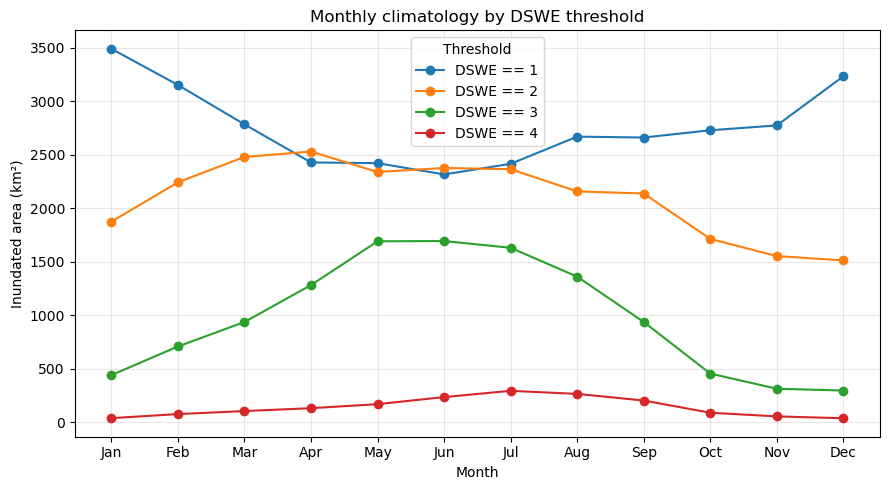

In [18]:

# Quick line plot of means
plt.figure(figsize=(9,5))
for col in clim_mean_km2.columns:
    plt.plot(clim_mean_km2.index, clim_mean_km2[col], marker='o', label=col)
plt.xlabel("Month")
plt.ylabel("Inundated area (km²)")
plt.title("Monthly climatology by DSWE threshold")
plt.grid(True, alpha=0.3)
plt.legend(title="Threshold")
plt.tight_layout()
plt.show()

## Want counts of places that are never inundated (1 only climatology)
## Climatology of class1 in areas where class2 or greater rarely.
## maybe lets start with a map of class 2 and greater frequency.  

In [19]:
import ee
import numpy as np

# -----------------------------
# Parameters (edit as needed)
# -----------------------------
DSWE_BAND = 'dswe'
DSWE_CLASSES = [0, 1, 2, 3, 4]  # edit if needed
SCALE = 30
MAX_PIX = 1e13

# Transition encoding base:
# For classes 0..9, base=10 is fine. If you ever have >9 classes, use 100.
ENC_BASE = 10

# Years to process (edit)
YEARS = list(range(2017, 2021))  # e.g., 2017..2020

# Export settings
EXPORT_FOLDER = 'Okavango'


# -----------------------------
# Helpers
# -----------------------------
def get_month_img(ic, year, month):
    """Get monthly DSWE image for (year, month) from collection."""
    im = (ic.filter(ee.Filter.eq('year', int(year)))
            .filter(ee.Filter.eq('month', int(month)))
            .first())
    return ee.Image(im).select([DSWE_BAND])

def transition_img_for_year(ic, year, month_from=1, month_to=7):
    """
    Return an Image with bands:
      - trans: encoded transition code (from*ENC_BASE + to)
      - from: Jan DSWE class
      - to:   Jul DSWE class
    """
    im_from = get_month_img(ic, year, month_from).rename('from')
    im_to   = get_month_img(ic, year, month_to).rename('to')

    trans = im_from.multiply(ENC_BASE).add(im_to).rename('trans')
    return trans.addBands([im_from, im_to]).set({'year': int(year)})

def transition_code(from_class, to_class):
    return int(from_class) * ENC_BASE + int(to_class)

def mask_transition(trans_image, from_class, to_class):
    """Binary mask image where transition equals from->to."""
    code = transition_code(from_class, to_class)
    return trans_image.select('trans').eq(code)

def transition_histogram_feature(trans_image, year, geometry, scale=SCALE):
    """
    Build a Feature with:
      - year
      - pix_<code>  = pixel count with transition code
      - km2_<code>  = area in km^2 for transition code
    """
    trans = trans_image.select('trans')

    # Pixel counts per code
    hist = ee.Dictionary(trans.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=geometry,
        scale=scale,
        maxPixels=MAX_PIX
    ).get('trans'))

    # Convert pixel counts -> km^2
    # (pixel area in km^2 at native scale; if you use reduceRegion with scale=30,
    #  pixel counts * (30*30)/1e6 = 0.0009 km^2)
    pix_km2 = (scale * scale) / 1e6

    # Build property lists for all possible codes (optional: include only observed codes)
    props = ee.Dictionary({'year': int(year)})

    # include all combinations so CSV has consistent columns
    all_codes = [transition_code(a, b) for a in DSWE_CLASSES for b in DSWE_CLASSES]

    def add_code_props(d, code):
        code_str = str(code)
        pix = ee.Number(ee.Algorithms.If(hist.contains(code_str), hist.get(code_str), 0))
        d = ee.Dictionary(d)
        d = d.set(f'pix_{code_str}', pix)
        d = d.set(f'km2_{code_str}', pix.multiply(pix_km2))
        return d

    props = ee.Dictionary(ee.List(all_codes).iterate(add_code_props, props))
    return ee.Feature(None, props)


# -----------------------------
# Build per-year transition ImageCollection
# -----------------------------
trans_ic = ee.ImageCollection([transition_img_for_year(ls_dswe_collection, y) for y in YEARS])

# Example: single-year transition map
year_example = YEARS[-1]
trans_example = transition_img_for_year(ls_dswe_collection, year_example)

# Multi-year "mode" of transitions (per pixel: most common Jan->Jul transition code)
trans_mode = trans_ic.select('trans').reduce(ee.Reducer.mode()).rename('trans_mode')

# Multi-year frequency for specific transitions (per pixel: fraction of years with that transition)
def freq_transition(trans_ic, from_class, to_class):
    code = transition_code(from_class, to_class)
    occurs = trans_ic.map(lambda im: ee.Image(im).select('trans').eq(code).rename('occurs'))
    return occurs.mean().rename(f'freq_{from_class}_to_{to_class}')

freq_1_to_0 = freq_transition(trans_ic, 1, 0)
freq_1_to_2 = freq_transition(trans_ic, 1, 2)


# -----------------------------
# Optional: compute AOI total areas for specific transitions for a given year
# -----------------------------
pixel_area_km2 = ee.Image.pixelArea().divide(1e6)

area_1_to_0 = pixel_area_km2.updateMask(mask_transition(trans_example, 1, 0)).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=okavango,
    scale=SCALE,
    maxPixels=MAX_PIX
)

area_1_to_2 = pixel_area_km2.updateMask(mask_transition(trans_example, 1, 2)).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=okavango,
    scale=SCALE,
    maxPixels=MAX_PIX
)

print("Example year:", year_example)
print("Area (km^2) 1→0:", area_1_to_0.getInfo())
print("Area (km^2) 1→2:", area_1_to_2.getInfo())


# -----------------------------
# Build per-year histogram FeatureCollection (counts + km2 by code)
# -----------------------------
hist_fc = ee.FeatureCollection([
    transition_histogram_feature(transition_img_for_year(ls_dswe_collection, y), y, okavango, scale=SCALE)
    for y in YEARS
])


# -----------------------------
# Exports
# -----------------------------
if run_exports:
    # 1) Single-year transition code map (GeoTIFF)
    ee.batch.Export.image.toDrive(
        image=trans_example.select('trans'),
        description=f'dswe_transition_jan_jul_{year_example}',
        folder=EXPORT_FOLDER,
        fileNamePrefix=f'dswe_transition_jan_jul_{year_example}',
        region=okavango,
        scale=SCALE,
        maxPixels=MAX_PIX
    ).start()

    # 2) Multi-year mode transition map (GeoTIFF)
    ee.batch.Export.image.toDrive(
        image=trans_mode,
        description='dswe_transition_jan_jul_mode',
        folder=EXPORT_FOLDER,
        fileNamePrefix='dswe_transition_jan_jul_mode',
        region=okavango,
        scale=SCALE,
        maxPixels=MAX_PIX
    ).start()

    # 3) Multi-year frequency maps for selected transitions (GeoTIFF)
    ee.batch.Export.image.toDrive(
        image=freq_1_to_0,
        description='dswe_transition_freq_1_to_0',
        folder=EXPORT_FOLDER,
        fileNamePrefix='dswe_transition_freq_1_to_0',
        region=okavango,
        scale=SCALE,
        maxPixels=MAX_PIX
    ).start()

    ee.batch.Export.image.toDrive(
        image=freq_1_to_2,
        description='dswe_transition_freq_1_to_2',
        folder=EXPORT_FOLDER,
        fileNamePrefix='dswe_transition_freq_1_to_2',
        region=okavango,
        scale=SCALE,
        maxPixels=MAX_PIX
    ).start()

    # 4) Per-year transition histogram CSV (Drive)
    ee.batch.Export.table.toDrive(
        collection=hist_fc,
        description='dswe_transition_jan_jul_hist_by_year',
        folder=EXPORT_FOLDER,
        fileNamePrefix='dswe_transition_jan_jul_hist_by_year',
        fileFormat='CSV'
    ).start()


Example year: 2020


EEException: Image.select: Parameter 'input' is required and may not be null.

In [ ]:
df_ls_multi.head()

In [ ]:
# make both plots use a shared color map so each threshold’s
# monthly series and its rolling mean use the SAME color.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
from matplotlib.lines import Line2D

PIXEL_KM2 = 0.0009  # 30 m pixel area
THRESHOLDS = (0, 1, 2)
ROLLING_MONTHS = 12

def _parse_class_codes(df):
    pat = re.compile(r"^count_dswe_(\-?\d+)$")
    codes, cols = [], []
    for c in df.columns:
        m = pat.match(c)
        if m:
            codes.append(int(m.group(1)))
            cols.append(c)
    order = np.argsort(codes)
    return [codes[i] for i in order], [cols[i] for i in order]

def dswe_threshold_timeseries(df_ls_multi, thresholds=(0,1,2,3), to_km2=True,
                              reindex_monthly=True, rolling_months=None):
    """
    Build a wide monthly time series DataFrame with columns like 'DSWE> 0', 'DSWE> 1', ...
    Optionally adds matching rolling columns like 'DSWE> 0 (roll12)'.
    """
    df = df_ls_multi.copy()
    if not np.issubdtype(df['date'].dtype, np.datetime64):
        df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').set_index('date')

    if reindex_monthly:
        monthly_idx = pd.date_range(df.index.min(), df.index.max(), freq='MS')
        df = df.reindex(monthly_idx)

    # Find DSWE class columns and map code -> column
    codes, class_cols = _parse_class_codes(df.reset_index().rename(columns={'index':'date'}))
    if not class_cols:
        raise ValueError("No columns like 'count_dswe_<code>' found.")
    df[class_cols] = df[class_cols].fillna(0)

    code_to_col = dict(zip(codes, class_cols))

    # Build each threshold series
    out = pd.DataFrame(index=df.index)
    for t in thresholds:
        cols_gt_t = [code_to_col[c] for c in codes if c > t]
        series = df[cols_gt_t].sum(axis=1) if cols_gt_t else pd.Series(0, index=df.index)
        if to_km2:
            series = series * PIXEL_KM2
        out[f'DSWE> {t}'] = series

    # Optional rolling mean
    if rolling_months:
        for col in out.columns:
            out[f'{col} (roll{rolling_months})'] = out[col].rolling(rolling_months, min_periods=1).mean()

    return out

# ---- compute the monthly time series (km²) ----
ts_km2 = dswe_threshold_timeseries(
    df_ls_multi,
    thresholds=THRESHOLDS,
    to_km2=True,
    reindex_monthly=True,
    rolling_months=None
)

# ---- compute monthly + rolling (km²) ----
ts_km2_sm = dswe_threshold_timeseries(
    df_ls_multi,
    thresholds=THRESHOLDS,
    to_km2=True,
    reindex_monthly=True,
    rolling_months=ROLLING_MONTHS
)

# ---- shared color map keyed by base labels so colors match across BOTH plots ----
base_labels = [f'DSWE> {t}' for t in THRESHOLDS]
palette = plt.rcParams['axes.prop_cycle'].by_key().get('color', None) or \
          ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C9']
color_map = {lbl: col for lbl, col in zip(base_labels, cycle(palette))}

# ========== Plot 1: monthly time series (no rolling), consistent colors ==========
plt.figure(figsize=(11,4))
for lbl in base_labels:
    if lbl in ts_km2.columns:
        plt.plot(ts_km2.index, ts_km2[lbl], label=lbl, linewidth=1.2, color=color_map[lbl])
plt.xlabel('Date')
plt.ylabel('Inundated area (km²)')
plt.title('Monthly DSWE threshold time series')
plt.grid(True, alpha=0.3)
plt.legend(title='Threshold')
plt.tight_layout()
plt.show()

# ========== Plot 2: monthly + rolling, rolling uses SAME color as monthly ==========
plt.figure(figsize=(11,4))
ax = plt.gca()

for lbl in base_labels:
    if lbl not in ts_km2_sm.columns:
        continue
    # monthly (thin)
    ax.plot(ts_km2_sm.index, ts_km2_sm[lbl], linewidth=0.9, alpha=0.7,
            color=color_map[lbl], label=lbl)

    # rolling (thick), same color
    roll_col = f'{lbl} (roll{ROLLING_MONTHS})'
    if roll_col in ts_km2_sm.columns:
        ax.plot(ts_km2_sm.index, ts_km2_sm[roll_col], linewidth=2.2, color=color_map[lbl])

ax.set_xlabel('Date')
ax.set_ylabel('Inundated area (km²)')
ax.set_title(f'Monthly DSWE threshold time series (with {ROLLING_MONTHS}-mo rolling mean)')
ax.grid(True, alpha=0.3)

# two legends: thresholds (colors) and line meaning (styles)
th_handles = [Line2D([0],[0], color=color_map[lbl], lw=2.0) for lbl in base_labels]
th_legend  = ax.legend(th_handles, base_labels, title='Threshold', loc='upper left')

style_handles = [
    Line2D([0],[0], color='k', lw=0.9, alpha=0.7, label='Monthly'),
    Line2D([0],[0], color='k', lw=2.2, label=f'{ROLLING_MONTHS}-mo rolling'),
]
style_legend = ax.legend(style_handles, ['Monthly', f'{ROLLING_MONTHS}-mo rolling'],
                         title='Line meaning', loc='upper right')
ax.add_artist(th_legend)

plt.tight_layout()
plt.show()




DSWE > 0 (blue) is consistently far above the other lines, DSWE > 1 (orange) is smaller, and DSWE > 2 (open‑water‑leaning) are much smaller still—i.e., most inundation in the Okavango is vegetated/partial water (classes 2–1) rather than large expanses of deep, clear open water (classes 4–3). 

The Okavango is dominated by permanent/seasonal swamps with papyrus (Cyperus papyrus), reeds (Phragmites), and floodplain grasses; open clear water exists but is a minor habitat embedded within vegetated wetlands. 
Our DSWE pattern (large total inundation, small open‑water share) aligns with this ecology.

Hydrologically, the system is a flood‑pulse wetland with very high evapotranspiration losses, so broad shallow/vegetated flooding is expected rather than persistent deep open water across the floodplain (Milzow, 2009).

DSWE is designed to detect not only open water but also water mixed with vegetation or soils. 
Using our project’s class convention (4 high‑confidence → 1 low‑confidence/wetland), the time series shows that all inundation (DSWE > 0) dwarfs the open‑water‑like component (DSWE > 2 or > 3). Thus, most of the Okavango’s flooded area occurs as inundated vegetation/partial surface water rather than as large open‑water patches.

In [ ]:
# --- Sentinel-2 DSWE monthly pixel-count time series (DSWE > 0) ---

# Helper to attach (date, count) to each Sentinel-2 image
def add_pixel_count_s2(img):
    # If no DSWE_bin, use: gt0 = img.select('dswe').gt(0)
    gt0 = img.select('DSWE_bin')
    count = gt0.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=okavango,
        scale=10,
        maxPixels=1e13
    ).get(gt0.bandNames().get(0))  # fetch the band key safely

    year  = ee.Number.parse(img.get('year'))
    month = ee.Number.parse(img.get('month'))
    date  = ee.Date.fromYMD(year, month, 1)
    return img.set({'count': count, 'date': date.format('YYYY-MM')})

# Build the time series (server-side), sorted by year then month
ts_ic_s2 = (s2_dswe
            .sort('year')
            .sort('month')
            .map(add_pixel_count_s2))

# Convert to a FeatureCollection of {date, count}
ts_fc_s2 = ee.FeatureCollection(
    ts_ic_s2.map(lambda im: ee.Feature(None, {
        'date': im.get('date'),
        'count': im.get('count')
    }))
)

# ---- Pandas DataFrame (array-based, lightweight fetch) ----
import pandas as pd

dates_s2  = ts_fc_s2.aggregate_array('date').getInfo()
counts_s2 = ts_fc_s2.aggregate_array('count').getInfo()

df_s2 = pd.DataFrame({'date': dates_s2, 'count': counts_s2})
df_s2['date'] = pd.to_datetime(df_s2['date'], format='%Y-%m', errors='coerce')

df_s2.head()


In [ ]:
# --- Inman & Lyons monthly pixel-count time series (values > 0) ---

IL_merged = IL_og.filter(ee.Filter.lte('year', '2019')).merge(IL_collection)
print (IL_merged.size().getInfo())
# keep IL_og only through 2019
il_og_pre2019 = IL_og.filter(ee.Filter.lte('year', '2019'))

# list of years already covered (as strings, distinct)
years_in_og = il_og_pre2019.aggregate_array('year').distinct()

# keep only those images in IL_Collection whose 'year' is not in years_in_og
# (ee.Filter.inList(...).Not() excludes matching years)
il_coll_missing_years = IL_collection.filter(
    ee.Filter.inList('year', years_in_og).Not()
)

# merge: first collection + only-missing-years from second
IL_merged = il_og_pre2019.merge(il_coll_missing_years)
print (IL_merged.size().getInfo())

In [ ]:
# Helper: attach (date, count) for each IL image
def add_pixel_count_il(img):
    # Use the first band (IL products can have varying names); rename for consistency
    il = img.select(0).rename('il')
    gt0 = il.eq(1)  # treat >0 as inundated

    count = gt0.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=okavango,
        scale=30,          # IL maps are Landsat-derived (30 m)
        maxPixels=1e13
    ).get('il')

    # Build a date from the 'year' property; IL images are annual composites
    year = ee.Number.parse(img.get('year'))
    date = ee.Date.fromYMD(year, 1, 1)  # use Jan 1 of that year for a consistent timestamp

    return img.set({'count': count, 'date': date.format('YYYY-MM')})

# Build time series (sorted by year for readability)
ts_ic_il = (IL_merged
            .sort('year')
            .map(add_pixel_count_il))

# To FeatureCollection of {date, count}
ts_fc_il = ee.FeatureCollection(
    ts_ic_il.map(lambda im: ee.Feature(None, {
        'date': im.get('date'),
        'count': im.get('count')
    }))
)


dates_il  = ts_fc_il.aggregate_array('date').getInfo()
counts_il = ts_fc_il.aggregate_array('count').getInfo()

df_il = pd.DataFrame({'date': dates_il, 'count': counts_il})
df_il['date'] = pd.to_datetime(df_il['date'], format='%Y-%m', errors='coerce')

print(df_il.head())


In [ ]:
img = IL_collection.first()  # or a specific year image
hist = img.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=okavango,
    scale=30,
    maxPixels=1e13
)
print(hist.getInfo())  # inspect keys 0,1,2,3 and their counts
print(img.bandNames().getInfo())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

PX30_TO_KM2 = 0.0009  # 30 m pixel area in km²

def jas_annual_mean(df: pd.DataFrame, label: str, value_col: str = 'area_km2'):
    """Return ['year', f'{label}_jas_mean_km2'] as July–September mean of `value_col`."""
    out = df.copy()
    out['date']  = pd.to_datetime(out['date'], errors='coerce')
    out['year']  = out['date'].dt.year
    out['month'] = out['date'].dt.month
    out = out[out['month'].isin([7, 8, 9])]
    ann = (out.groupby('year', as_index=False)[value_col]
              .mean()
              .rename(columns={value_col: f'{label}_jas_mean_km2'}))
    return ann

def annual_max(df: pd.DataFrame, label: str, value_col: str = 'area_km2'):
    """Return ['year', f'{label}_jas_mean_km2'] as July–September mean of `value_col`."""
    out = df.copy()
    out['date']  = pd.to_datetime(out['date'], errors='coerce')
    out['year']  = out['date'].dt.year
    out['month'] = out['date'].dt.month
    out = out[out['month'].isin([4,5,6,7, 8, 9, 10,11, 12])]
    ann = (out.groupby('year', as_index=False)[value_col]
              .max()
              .rename(columns={value_col: f'{label}_max_km2'}))
    return ann

# 1) Landsat: pixels -> km²
df_ls_km2 = df_ls.copy()
df_ls_km2['area_km2'] = df_ls_km2['count'] * PX30_TO_KM2
ls_ann = jas_annual_mean(df_ls_km2, label='landsat')

ls_max = annual_max(df_ls_km2, label='landsat')


# 2) Sentinel-2: convert to 30 m-pixel equivalents (÷9), then -> km²
df_s2_km2 = df_s2.copy()
df_s2_km2['area_km2'] = (df_s2_km2['count'] / 9.0) * PX30_TO_KM2
s2_ann = jas_annual_mean(df_s2_km2, label='sentinel')

# 3) Inman & Lyons (30 m): pixels -> km², then annual mean (already annual timestamps)
df_il_km2 = df_il.copy()
df_il_km2['date'] = pd.to_datetime(df_il_km2['date'], errors='coerce')
df_il_km2['year'] = df_il_km2['date'].dt.year
il_ann = (df_il_km2.assign(area_km2=df_il_km2['count'] * PX30_TO_KM2)
                    .groupby('year', as_index=False)['area_km2']
                    .mean()
                    .rename(columns={'area_km2': 'il_annual_km2'}))

# Combine and plot
annual_km2 = (ls_ann.merge(ls_max, on='year', how='outer')
                    .merge(s2_ann, on='year', how='outer')
                    .merge(il_ann, on='year', how='outer')
                    .sort_values('year')
                    .reset_index(drop=True))

plt.figure(figsize=(9, 5))
plt.plot(annual_km2['year'], annual_km2['landsat_jas_mean_km2'], marker='o', linestyle = ":", label='Landsat (JAS mean)')
# plt.plot(annual_km2['year'], annual_km2['landsat_max_km2'], marker='s', linestyle = ":", label='Landsat (annual max)')
plt.plot(annual_km2['year'], annual_km2['sentinel_jas_mean_km2'], marker='o', linestyle = ":", label='Sentinel-2 (JAS mean)')
plt.plot(annual_km2['year'], annual_km2['il_annual_km2'],        marker='o', linestyle = ":", label='Inman & Lyons (annual)')
plt.xlabel('Year'); plt.ylabel('Inundated area (km²)')
plt.title('Okavango inundation area: Landsat vs Sentinel-2 vs Inman & Lyons')
plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
annual_km2.corr().round(2)['il_annual_km2']

In [ ]:
# annual_km2.to_csv("../data/annual_flood_area_km2.csv")

In [ ]:
import re
from pathlib import Path
from typing import Optional, Tuple, List
import xarray as xr

EARTH_RADIUS_M = 6_371_008.8  # meters

def _timestamp_from_filename(path: Path) -> pd.Timestamp:
    m = re.search(r"(\d{4})-(\d{2})", path.name)
    if not m:
        raise ValueError(f"Filename must contain YYYY-MM: {path.name}")
    y, mo = int(m.group(1)), int(m.group(2))
    return pd.Timestamp(year=y, month=mo, day=1)

def _cell_area_km2(lat_1d: np.ndarray, dlat_deg: float, dlon_deg: float) -> np.ndarray:
    """
    Per-row (constant lon width) cell area in km^2 for each latitude in lat_1d.
    """
    lat_1d = np.asarray(lat_1d, dtype=float)
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    area_m2 = (EARTH_RADIUS_M ** 2) * dlat * dlon * np.cos(np.deg2rad(lat_1d))
    return area_m2 / 1e6  # km^2


def monthly_inundation_df(
    crops_dir: str | Path,
    varname: Optional[str] = None,
    threshold: float = 0.5,) -> pd.DataFrame:
    """
    Compute total inundation area (km²) per month from okav_YYYY-MM.nc files.
    Assumes coordinates are named 'lat' and 'lon' and grid is regular.
    """
    crops_dir = Path(crops_dir)
    paths = sorted(crops_dir.glob("okav_*.nc"), key=lambda p: p.name)
    if not paths:
        raise FileNotFoundError(f"No okav_*.nc files found in {crops_dir}")

    rows: List[dict] = []

    for p in paths:
        ts = _timestamp_from_filename(p)

        ds = xr.open_dataset(p, decode_times=False)

        lat = ds["lat"].values
        lon = ds["lon"].values

        # pick variable
        if varname is None:
            # prefer something with "mask"/"water" in the name, else first data_var
            cand = [v for v in ds.data_vars if ("mask" in v.lower()) or ("water" in v.lower())]
            vname = cand[0] if cand else list(ds.data_vars)[0]
        else:
            vname = varname

        da = ds[vname]
        # if a time dim exists, take the first slice (monthly product)
        tdim = next((d for d in da.dims if d.lower().startswith("time")), None)
        if tdim is not None:
            da = da.isel({tdim: 0}).squeeze(drop=True)

        # ensure 1D lat/lon
        if lat.ndim != 1: lat = np.unique(lat)
        if lon.ndim != 1: lon = np.unique(lon)

        # grid spacing (deg) — assume regular grid
        dlat = float(np.abs(lat[1] - lat[0]))
        dlon = float(np.abs(lon[1] - lon[0]))

        # per-row cell area (km²), broadcast to full grid
        row_area = _cell_area_km2(lat, dlat, dlon)  # (nlat,)
        area_grid = np.repeat(row_area[:, None], len(lon), axis=1)  # (lat, lon)

        arr = np.asarray(da)
        mask = np.isfinite(arr) & (arr >= threshold)
        water_km2 = float((area_grid * mask).sum())

        rows.append({"date": ts, "km2": water_km2})
        ds.close()

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    return df

df_monthly = monthly_inundation_df("../data/cygnss_okavango_full/crops_nc_clip", threshold=0.5)
# Annual peak flood extent:
df_annual_max = df_monthly.groupby("year", as_index=False)["km2"].max().rename(columns={"km2":"annual_max_km2"})
df_jas_mean = df_monthly.query('month in [7,8,9]').groupby("year", as_index=False)["km2"].max().rename(columns={"km2":"annual_max_km2"})


In [ ]:
df_monthly.head()

In [ ]:
# Initialize Earth Engine
ee.Initialize()

# Your bbox: (min_lon, min_lat, max_lon, max_lat)
OKAV_BBOX  = (21.696, -22.223, 24.103, -18.221)
geom = ee.Geometry.BBox(*OKAV_BBOX)

# MODIS NDVI (Terra, 16-day, 250 m), Collection 6.1
ndvi_col = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
      .select('NDVI')
      .filterDate('2002-01-01', '2024-12-31')   # adjust as needed
      .filterBounds(geom)
)

def add_mean_ndvi(image):
    # spatial mean over your bbox
    mean = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=250,         # MOD13Q1 nominal resolution
        maxPixels=1e13
    ).get('NDVI')

    # attach date + mean as properties
    return (image
            .set('ndvi_mean', mean)
            .set('date', image.date().format('YYYY-MM-dd')))

# Map over collection
ndvi_with_mean = ndvi_col.map(add_mean_ndvi)

# Pull results client-side as lists
dates = ndvi_with_mean.aggregate_array('date').getInfo()
ndvi_means = ndvi_with_mean.aggregate_array('ndvi_mean').getInfo()

# Build DataFrame
df_ndvi = pd.DataFrame({
    'date': dates,
    # MOD13Q1 NDVI is scaled by 1e4
    'ndvi_mean': [v * 0.0001 if v is not None else None for v in ndvi_means]
})



In [ ]:
import re
from pathlib import Path
from typing import Optional, List

import xarray as xr
import numpy as np
import pandas as pd  # only needed for _timestamp_from_filename; optional


def _timestamp_from_filename(path: Path) -> pd.Timestamp:
    m = re.search(r"(\d{4})-(\d{2})", path.name)
    if not m:
        raise ValueError(f"Filename must contain YYYY-MM: {path.name}")
    y, mo = int(m.group(1)), int(m.group(2))
    return pd.Timestamp(year=y, month=mo, day=1)


def composite_inundation(
    crops_dir: str | Path,
    varname: Optional[str] = None,
    threshold: float = 0.5) -> xr.Dataset:
    """
    Build a composite flood extent from okav_YYYY-MM.nc files.

    Returns an xarray.Dataset with:
      - 'ever_wet': 1 where any month >= threshold, else 0
      - 'wet_count': number of months with value >= threshold
      - 'wet_frac': wet_count / N_months
    """
    crops_dir = Path(crops_dir)
    paths = sorted(crops_dir.glob("okav_*.nc"), key=lambda p: p.name)
    if not paths:
        raise FileNotFoundError(f"No okav_*.nc files found in {crops_dir}")

    lat_1d = lon_1d = None
    wet_count = None
    n_files = 0

    for p in paths:
        ds = xr.open_dataset(p, decode_times=False)

        lat = ds["lat"].values
        lon = ds["lon"].values

        # ensure 1D lat/lon
        if lat.ndim != 1:
            lat = np.unique(lat)
        if lon.ndim != 1:
            lon = np.unique(lon)

        # pick variable
        if varname is None:
            cand = [v for v in ds.data_vars if ("mask" in v.lower()) or ("water" in v.lower())]
            vname = cand[0] if cand else list(ds.data_vars)[0]
        else:
            vname = varname

        da = ds[vname]
        # if a time dim exists, take first slice (monthly product)
        tdim = next((d for d in da.dims if d.lower().startswith("time")), None)
        if tdim is not None:
            da = da.isel({tdim: 0}).squeeze(drop=True)

        arr = np.asarray(da)

        # initialize on first file
        if wet_count is None:
            lat_1d = lat
            lon_1d = lon
            wet_count = np.zeros_like(arr, dtype=np.int32)

        # wet where value >= threshold and finite
        wet = np.isfinite(arr) & (arr >= threshold)
        wet_count += wet.astype(np.int32)

        n_files += 1
        ds.close()

    ever_wet = (wet_count > 0).astype(np.uint8)
    wet_frac = wet_count.astype(float) / float(n_files)

    ds_out = xr.Dataset(
        {
            "ever_wet": (("lat", "lon"), ever_wet),
            "wet_count": (("lat", "lon"), wet_count),
            "wet_frac": (("lat", "lon"), wet_frac),
        },
        coords={"lat": lat_1d, "lon": lon_1d},
        attrs={
            "description": "CYGNSS composite flood extent",
            "threshold": threshold,
            "n_months": n_files,
        },
    )
    return ds_out


In [ ]:
# crops_dir = "../data/cygnss_okavango_full/crops_nc_clip"
ds_comp = composite_inundation(crops_dir, threshold=0.5)

plt.figure()
ds_comp["wet_frac"].plot()      # fraction of months inundated



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import folium
from folium.raster_layers import ImageOverlay
import branca.colormap as bcm
import geemap.foliumap as geemap   # ensures geemap.Map() is a folium map
import matplotlib.colors as mcolors
import matplotlib.cm as cm

da = ds_comp["wet_frac"].squeeze()

# Folium ImageOverlay expects the first row = north, so force lat descending
da = da.sortby("lat", ascending=False)
arr = da.to_numpy()

# Colormap to RGBA (0..255) with transparent NaNs
vmin, vmax = 0.0, 1.0
norm = np.clip((arr - vmin) / (vmax - vmin), 0, 1)
rgba = plt.cm.viridis(norm)
rgba[..., 3] = np.where(np.isfinite(arr), 0.85, 0.0)  # alpha
img = (rgba * 255).astype(np.uint8)

# Bounds: [[south, west], [north, east]]
lat_min, lat_max = float(da.lat.min()), float(da.lat.max())
lon_min, lon_max = float(da.lon.min()), float(da.lon.max())
bounds = [[lat_min, lon_min], [lat_max, lon_max]]

# Folium map (via geemap)
m = geemap.Map(center=[(lat_min + lat_max) / 2, (lon_min + lon_max) / 2], zoom=8)
ImageOverlay(image=img, bounds=bounds, name="wet_frac").add_to(m)

# Colorbar legend
# Colorbar legend (custom viridis)

colors = [mcolors.to_hex(cm.viridis(x)) for x in np.linspace(0, 1, 256)]
cb = bcm.LinearColormap(colors=colors, vmin=vmin, vmax=vmax)
cb.caption = "Fraction of months inundated"
cb.add_to(m)

folium.LayerControl().add_to(m)
m
# TODO: set zoom level, expand domain area

In [ ]:
import ee
import pandas as pd

# Initialize Earth Engine
ee.Initialize()

# Your bbox: (min_lon, min_lat, max_lon, max_lat)
OKAV_BBOX  = (21.696, -20.223, 24.103, -18.221)
geom = ee.Geometry.BBox(*OKAV_BBOX)

# ---------------------------------------------------------------------
# 1) DSWE composite mask
# ---------------------------------------------------------------------
DSWE_ASSET = 'projects/ee-okavango/assets/water_masks/composites/mean_DSWE_12122018_06152023'

dswe_img = ee.Image(DSWE_ASSET)

# Choose a threshold for "wet" (tune this!)
DSWE_THRESH = 0.5  # e.g., mean DSWE > 0.5 = often wet

# Boolean mask: 1 where "wet", 0 elsewhere
water_mask = dswe_img.gt(DSWE_THRESH)

# ---------------------------------------------------------------------
# 2) MODIS NDVI collection
# ---------------------------------------------------------------------
ndvi_col = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
      .select('NDVI')
      .filterDate('2002-01-01', '2025-12-31')   # adjust as needed
      .filterBounds(geom)
)

def add_mean_ndvi_masked(image):
    # Apply DSWE water mask to NDVI (mask is auto-aligned/reprojected)
    ndvi_masked = image.updateMask(water_mask)

    # Spatial mean over bbox, but only where water_mask == 1
    mean = ndvi_masked.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=250,         # MOD13Q1 nominal resolution
        maxPixels=1e13
    ).get('NDVI')

    # Attach date + mean as properties
    return (image
            .set('ndvi_mean_dswe_masked', mean)
            .set('date', image.date().format('YYYY-MM-dd')))

# Map over collection
ndvi_with_mean = ndvi_col.map(add_mean_ndvi_masked)

# Pull results client-side as lists
dates = ndvi_with_mean.aggregate_array('date').getInfo()
ndvi_means = ndvi_with_mean.aggregate_array('ndvi_mean_dswe_masked').getInfo()

# Build DataFrame
df_ndvi = pd.DataFrame({
    'date': dates,
    # MOD13Q1 NDVI is scaled by 1e4
    'ndvi_mean': [v * 0.0001 if v is not None else None for v in ndvi_means]
})

df_ndvi['date'] = pd.to_datetime(df_ndvi['date'])
print(df_ndvi.head())


In [ ]:
%%time
# import ee
# import pandas as pd
# import geemap

# ee.Initialize()

OKAV_BBOX  = (21.696, -20.223, 24.103, -18.221)  # (min_lon, min_lat, max_lon, max_lat)
bbox_geom = ee.Geometry.BBox(*OKAV_BBOX)

# --- 1x1° grid over the bbox (anchored at bbox min) ---
def make_1deg_grid(bbox, step_deg=1.0):
    min_lon, min_lat, max_lon, max_lat = bbox
    feats = []
    col = 0
    lon = min_lon
    while lon < min_lon + 5:
        row = 0
        lat = min_lat
        while lat < min_lat + 5:
            cell = ee.Geometry.Rectangle(
                [lon, lat, lon + step_deg, lat + step_deg],
                proj="EPSG:4326",
                geodesic=False
            ).intersection(bbox_geom, ee.ErrorMargin(1))

            feats.append(
                ee.Feature(cell, {
                    "cell_id": f"c{col:02d}_r{row:02d}",
                    "lon0": lon, "lat0": lat,
                    "lon1": lon + step_deg, "lat1": lat + step_deg,
                    "col": col, "row": row
                })
            )
            lat += step_deg
            row += 1
        lon += step_deg
        col += 1
    return ee.FeatureCollection(feats)

grid_fc = make_1deg_grid(OKAV_BBOX, step_deg=1.0)

# --- DSWE composite mask (keep only "wet" pixels) ---
DSWE_ASSET = "projects/ee-okavango/assets/water_masks/composites/mean_DSWE_12122018_06152023"
DSWE_THRESH = 0.5
water_mask = ee.Image(DSWE_ASSET).gt(DSWE_THRESH)

# --- MODIS NDVI collection ---
ndvi_col = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
      .select("NDVI")
      .filterDate("2018-01-01", "2025-12-31")
      .filterBounds(bbox_geom)
)

reducer = ee.Reducer.mean().setOutputs(["ndvi_mean"])

def per_image_fc(img):
    img = ee.Image(img)
    date = img.date().format("YYYY-MM-dd")

    ndvi = (
        img.select("NDVI")
           .multiply(0.0001)          # MOD13Q1 scale factor
           .updateMask(water_mask)    # keep only wet pixels (use .updateMask(water_mask.Not()) to EXCLUDE wet)
    )

    fc = ndvi.reduceRegions(
        collection=grid_fc,
        reducer=reducer,
        scale=250,
#         maxPixels=1e13,
        tileScale=4
    )
    return fc.map(lambda f: f.set("date", date))

# Iterate over images to build one big FeatureCollection
fc_all = ee.FeatureCollection(
    ndvi_col.iterate(
        lambda img, acc: ee.FeatureCollection(acc).merge(per_image_fc(img)),
        ee.FeatureCollection([])
    )
)

# Pull to pandas
df_ndvi_grid = geemap.ee_to_df(fc_all)
df_ndvi_grid["date"] = pd.to_datetime(df_ndvi_grid["date"])

# Keep the columns you care about
df_ndvi_grid = df_ndvi_grid[["date", "cell_id", "lon0", "lat0", "lon1", "lat1", "ndvi_mean"]].sort_values(["date", "cell_id"])
df_ndvi_grid.head()


In [ ]:

PX30_TO_KM2 = 0.0009  # 30 m pixel area in km²

def prep_monthly(df: pd.DataFrame, sensor: str):
    """
    From a monthly df with ['date','count'], return a monthly series in km²:
      - Landsat: count * 0.0009
      - Sentinel-2: (count / 9) * 0.0009
    Aggregates by month (mean if multiple rows per month).
    """
    out = df[['date','count']].copy()
    out['date'] = pd.to_datetime(out['date'], errors='coerce')
    out = out.dropna(subset=['date'])
    out['month'] = out['date'].dt.to_period('M').dt.to_timestamp()
    out['year'] = out['date'].dt.to_period('Y').dt.to_timestamp()    

    if sensor == 'landsat':
        out['km2'] = out['count'] * PX30_TO_KM2
    elif sensor == 'sentinel':
        out['km2'] = (out['count'] / 9.0) * PX30_TO_KM2
    else:
        raise ValueError("sensor must be 'landsat' or 'sentinel'")

    # average if multiple entries in a month
    return (out.groupby('month', as_index=True)[['km2','year']]
               .mean()
               .sort_index())

# Build monthly series
ls_monthly = prep_monthly(df_ls, sensor='landsat').query('year > 2017')
s2_monthly = prep_monthly(df_s2, sensor='sentinel')

# Create a complete monthly index spanning both series
start = min(ls_monthly.index.min(), s2_monthly.index.min())
end   = max(ls_monthly.index.max(), s2_monthly.index.max())
full_months = pd.date_range(start=start, end=end, freq='MS')  # month starts

ls_full = ls_monthly.reindex(full_months)
s2_full = s2_monthly.reindex(full_months)

# list missing months (where either is NaN)
missing_ls = ls_full[ls_full.isna()].index.strftime('%Y-%m').tolist()
missing_s2 = s2_full[s2_full.isna()].index.strftime('%Y-%m').tolist()
print("Missing months (Landsat):", missing_ls[:10], "… total", len(missing_ls))
print("Missing months (Sentinel):", missing_s2[:10], "… total", len(missing_s2))

# Plot monthly DSWE area (km²), dashed lines with markers
plt.figure(figsize=(11, 5))
plt.plot(ls_full.index, ls_full['km2'], marker='o', linestyle='--', label='Landsat DSWE>0 (km²)')
plt.plot(s2_full.index, s2_full['km2'], marker='o', linestyle='--', label='Sentinel-2 DSWE>0 (km²)')
plt.xlabel('Month')
plt.ylabel('Inundated area (km²)')
plt.title('Okavango Monthly Inundation Area: Landsat vs Sentinel-2 (DSWE>0)')
plt.plot(df_monthly['date'], df_monthly['km2'], marker='o', linestyle='--', label='CYGNSS (km²)')
plt.legend()

In [ ]:
PX30_TO_KM2 = 0.0009  # 30 m pixel area in km²

def prep_monthly(df: pd.DataFrame, sensor: str):
    """
    From a monthly df with ['date','count'], return a monthly series in km²:
      - Landsat: count * 0.0009
      - Sentinel-2: (count / 9) * 0.0009
    Aggregates by month (mean if multiple rows per month).
    """
    out = df[['date','count']].copy()
    out['date'] = pd.to_datetime(out['date'], errors='coerce')
    out = out.dropna(subset=['date'])
    out['month'] = out['date'].dt.to_period('M').dt.to_timestamp()
    out['year'] = out['date'].dt.to_period('Y').dt.to_timestamp()    

    if sensor == 'landsat':
        out['km2'] = out['count'] * PX30_TO_KM2
    elif sensor == 'sentinel':
        out['km2'] = (out['count'] / 9.0) * PX30_TO_KM2
    else:
        raise ValueError("sensor must be 'landsat' or 'sentinel'")

    # average if multiple entries in a month
    return (out.groupby('month', as_index=True)[['km2','year']]
               .mean()
               .sort_index())

# Build monthly series
ls_monthly = prep_monthly(df_ls, sensor='landsat').query('year > 2017')
s2_monthly = prep_monthly(df_s2, sensor='sentinel')

# Create a complete monthly index spanning both series
start = min(ls_monthly.index.min(), s2_monthly.index.min())
end   = max(ls_monthly.index.max(), s2_monthly.index.max())
full_months = pd.date_range(start=start, end=end, freq='MS')  # month starts

ls_full = ls_monthly.reindex(full_months)
s2_full = s2_monthly.reindex(full_months)

# list missing months (where either is NaN)
missing_ls = ls_full[ls_full.isna()].index.strftime('%Y-%m').tolist()
missing_s2 = s2_full[s2_full.isna()].index.strftime('%Y-%m').tolist()
print("Missing months (Landsat):", missing_ls[:10], "… total", len(missing_ls))
print("Missing months (Sentinel):", missing_s2[:10], "… total", len(missing_s2))

# --- NDVI monthly series ---
# df_ndvi is assumed to have columns ['date', 'ndvi_mean']
ndvi_monthly = (
    df_ndvi
      .assign(date=pd.to_datetime(df_ndvi['date']))
      .groupby(pd.Grouper(key='date', freq='MS'))['ndvi_mean']
      .mean()
      .sort_index()
)

# Align NDVI with same monthly index
ndvi_full = ndvi_monthly.reindex(full_months)

# --- Plot: DSWE area (km²) + NDVI ---
fig, ax1 = plt.subplots(figsize=(11, 5))

# DSWE (Landsat/S2/CYGNSS) on left y-axis
line_ls, = ax1.plot(ls_full.index, ls_full['km2'], marker='o', linestyle='--',
                    label='Landsat DSWE>0 (km²)')

# line_s2, = ax1.plot(s2_full.index, s2_full['km2'], marker='o', linestyle='--',
#                     label='Sentinel-2 DSWE>0 (km²)')

line_cyg, = ax1.plot(df_monthly['date'], df_monthly['km2'], marker='o', c = 'C3', linestyle='--',
                     label='CYGNSS inundation (km²)')

ax1.set_xlabel('Month')
ax1.set_ylabel('Inundated area (km²)')
ax1.set_title('Okavango Monthly Inundation Area vs NDVI')

# NDVI on right y-axis
ax2 = ax1.twinx()
line_ndvi, = ax2.plot(ndvi_full.index, ndvi_full.values, marker='s', linestyle='--', c = 'C2',
                      label='Mean NDVI')
ax2.set_ylabel('NDVI')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax2.set_ylim(0,1)
plt.tight_layout()
plt.show()


In [ ]:
# Assume you already have:
# ls_full, s2_full from prep_monthly + reindex
# df_monthly  (CYGNSS, with columns ['date','km2'])
# df_ndvi     (with ['date','ndvi_mean'])

# 1) Monthly CYGNSS series on the same monthly index
cyg_monthly = (
    df_monthly
      .assign(date=pd.to_datetime(df_monthly['date']))
      .groupby(pd.Grouper(key='date', freq='MS'))['km2']
      .mean()
      .sort_index()
)

# 2) Monthly NDVI series
ndvi_monthly = (
    df_ndvi
      .assign(date=pd.to_datetime(df_ndvi['date']))
      .groupby(pd.Grouper(key='date', freq='MS'))['ndvi_mean']
      .mean()
      .sort_index()
)

# 3) Build one combined monthly index
start = min(ls_full.index.min(), s2_full.index.min(), cyg_monthly.index.min(), ndvi_monthly.index.min())
end   = max(ls_full.index.max(), s2_full.index.max(), cyg_monthly.index.max(), ndvi_monthly.index.max())
full_months = pd.date_range(start=start, end=end, freq='MS')

# 4) Reindex all series onto that index
ls_series   = ls_full['km2'].reindex(full_months)
s2_series   = s2_full['km2'].reindex(full_months)
cyg_series  = cyg_monthly.reindex(full_months)
ndvi_series = ndvi_monthly.reindex(full_months)

# 5) One merged DataFrame
df_all = pd.DataFrame({
    'ls_km2':   ls_series,
    's2_km2':   s2_series,
    'cyg_km2':  cyg_series,
    'ndvi':     ndvi_series,
}, index=full_months)

df_all.index.name = 'month'
df_all['year'] = df_all.index.year
df_all['month'] = df_all.index.month

print(df_all.query("cyg_km2 > 0").head())


In [ ]:
# 1) Subset from August 2018 onward
df_sub = df_all.loc['2018-08-01':].copy()

# 2) Min–max scale each series to [0, 1]
cols = ['ls_km2', 's2_km2', 'cyg_km2', 'ndvi']

for col in cols:
    col_min = df_sub[col].min()
    col_max = df_sub[col].max()
    df_sub[col] = (df_sub[col] - col_min) / (col_max - col_min)

df_sub['ls_delta'] = df_sub['ls_km2']  -  df_sub['cyg_km2'] 
df_sub['s2_delta'] = df_sub['s2_km2']  - df_sub['cyg_km2']    

# 3) Remove monthly mean (climatology) from each scaled series
month_index = df_sub.index.month

# this gives anomalies: value - mean for that calendar month
df_anom = df_sub.copy()
df_anom[cols] = df_sub[cols].groupby(month_index).transform(lambda x: x - x.mean())

df_anom['ls_delta'] = df_anom['ls_km2'] - df_anom['cyg_km2'] 
df_anom['s2_delta'] = df_anom['s2_km2'] - df_anom['cyg_km2']   
# optional: inspect
df_anom.head()


In [ ]:
plt.scatter(df_sub['ndvi'], df_sub['ls_delta'], c = df_sub['month'])
plt.xlabel("NDVI")
plt.ylabel("DSWE mimus CYNSS")

# Maybe just want area that floods!

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(df_sub.index, df_sub['cyg_km2'] - df_sub['ls_km2'], marker='o', 
        linestyle='--', label='CYGNSS minus DSWE (landsat)')
ax.plot(df_sub.index, df_sub['cyg_km2'] - df_sub['s2_km2'], marker='o', 
        linestyle='--', label='CYGNSS minus DSWE (s2)')
ax.plot(df_sub.index, df_sub['ndvi']/2,   marker='s', linestyle='-',  label='NDVI (scaled)')

ax.set_xlabel('Month')
ax.set_ylabel('Scaled value (0–1)')
ax.set_title('Okavango: Inundation & NDVI (scaled, Aug 2018 onward)')
ax.legend()
plt.tight_layout()
plt.show()
# This can be better! 

In [ ]:
df_anom.drop('year', axis = 1).drop('month', axis = 1).corr().round(2)

In [ ]:
df_anom.query("month < 9").drop(['year', 'month'], axis = 1).corr().round(2)

In [ ]:
df_anom.query("month >= 9").drop(['year', 'month'], axis = 1).corr().round(2)

In [ ]:
# Pick a clear, color-blind friendly palette
COLORS = {
    'Landsat (JAS mean)':        'C0',
    'Sentinel-2 (JAS mean)':     'C1',
    'Inman & Lyons (annual)':    'C2',
    'CYGNSS':                    'C3',    
}

def plot_gapped(years, values, label, marker='o', linestyle='--', color=None):
    years = list(years); values = list(values)
    seg_x, seg_y, prev_year, segments = [], [], None, []

    for y, v in zip(years, values):
        if pd.isna(v):
            if seg_x: segments.append((seg_x, seg_y))
            seg_x, seg_y, prev_year = [], [], None
            continue
        if prev_year is None or y != prev_year + 1:
            if seg_x: segments.append((seg_x, seg_y))
            seg_x, seg_y = [y], [v]
        else:
            seg_x.append(y); seg_y.append(v)
        prev_year = y
    if seg_x: segments.append((seg_x, seg_y))

    for x, y in segments:
        if len(x) == 1:
            plt.plot(x, y, marker=marker, linestyle='none', color=color, label=label)
        else:
            plt.plot(x, y, marker=marker, linestyle=linestyle, color=color, label=label)
        label = None  # avoid duplicate legend entries

plt.figure(figsize=(9, 4))
plot_gapped(annual_km2['year'], annual_km2['landsat_jas_mean_km2'],
            'Landsat (JAS mean)',        color=COLORS['Landsat (JAS mean)'])
plot_gapped(annual_km2['year'], annual_km2['sentinel_jas_mean_km2'],
            'Sentinel-2 (JAS mean)',  color=COLORS['Sentinel-2 (JAS mean)'])
plot_gapped(annual_km2['year'], annual_km2['il_annual_km2'],
            'Inman & Lyons (annual)',    color=COLORS['Inman & Lyons (annual)'])

plot_gapped(df_jas_mean['year'], df_jas_mean['annual_max_km2'],
            'CYGNSS (JAS mean)',    color=COLORS['CYGNSS'])

plt.xlabel('Year'); plt.ylabel('Inundated area (km²)')
plt.title('Okavango inundated area: Landsat vs Sentinel-2 vs Inman & Lyons')
plt.legend(); plt.tight_layout(); plt.show()


TODO: Side by side map of landsat, sentinel, IL and CYNSS
 


In [ ]:
ls_monthly.head()

In [ ]:

def monthly_timeseries(df: pd.DataFrame, sensor: str) -> pd.Series:
    """
    From a monthly df with columns ['date','count'], compute the mean DSWE>0 area (km²)
    for each calendar month (Jan..Dec) averaged across all years.
    sensor: 'landsat' or 'sentinel' (sentinel is scaled ÷9 to 30 m eq.)
    Returns a Series indexed 1..12 (month) with km² means.
    """
    out = df[['date','count']].copy()
    out['date'] = pd.to_datetime(out['date'], errors='coerce')
    out = out.dropna(subset=['date'])
    if sensor == 'landsat':
        out['km2'] = out['count'] * PX30_TO_KM2
    elif sensor == 'sentinel':
        out['km2'] = (out['count'] / 9.0) * PX30_TO_KM2
    else:
        raise ValueError("sensor must be 'landsat' or 'sentinel'")
    out['month'] = out['date'].dt.month
    out['year'] = out['date'].dt.year    
    # average over all years per calendar month; NaNs are ignored by default
    return out#.groupby('month')['km2'].mean().reindex(range(1,13))

# compute monthlyatologies
ls_monthly = monthly_timeseries(df_ls, sensor='landsat')
s2_monthly = monthly_timeseries(df_s2, sensor='sentinel')

# # make nice month labels
months = [calendar.month_abbr[m] for m in range(1, 13)]

# warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")
 
# # plot (dashed lines with markers)
# plt.figure(figsize=(9, 4.5))
# sns.lineplot(ls_monthly.query("year > 2018 and year != 2021"), x = 'month', y = 'km2',label='Landsat DSWE>0 (km²)')
# sns.lineplot(s2_monthly.query("year > 2018 and year != 2021").dropna(), x = 'month', y = 'km2',label='Sentinel-2 DSWE>0 (km²)')
# plt.xlabel('Month'); plt.ylabel('Mean inundated area (km²)')
# plt.title('Okavango Monthly timeseries of DSWE>0 Area (Averaged over Years)')




In [ ]:
import calendar
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")

# --- CYGNSS prep (df_monthly already has date + km2) ---
cyg = df_monthly.copy()
cyg['date']  = pd.to_datetime(cyg['date'], errors='coerce')
cyg = cyg.dropna(subset=['date'])
cyg['month'] = cyg['date'].dt.month
cyg['year']  = cyg['date'].dt.year

# If you want CYGNSS on the same “post-2018, exclude 2021” basis:
cyg_plot = cyg.query("year > 2018 and year != 2021")

plt.figure(figsize=(9, 4.5))
sns.lineplot(ls_monthly.query("year > 2018 and year != 2021"), x='month', y='km2',
             label='Landsat DSWE>0 (km²)')
sns.lineplot(s2_monthly.query("year > 2018 and year != 2021").dropna(), x='month', y='km2',
             label='Sentinel-2 DSWE>0 (km²)')
sns.lineplot(cyg_plot, x='month', y='km2', label='CYGNSS water (km²)')
plt.xlabel('Month'); plt.ylabel('Mean inundated area (km²)')
plt.title('Okavango Monthly Inundated Area (Averaged over Years)')
plt.xticks(ticks=range(1,13), labels=[calendar.month_abbr[m] for m in range(1,13)])
plt.tight_layout()

# TODO: comare DSWE > 1 and 

In [ ]:
# Save pandas DataFrames to ../data as CSVs
# Expects: ls_clim, s2_clim (pandas DataFrames or Series)

from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

def save_df(obj, fname):
    if isinstance(obj, pd.Series):
        obj = obj.to_frame(name=obj.name or "value")
    if not isinstance(obj, pd.DataFrame):
        raise TypeError(f"{fname}: expected pandas DataFrame/Series, got {type(obj).__name__}")
    out = DATA_DIR / fname
    obj.to_csv(out, index=True, na_rep="", float_format="%.6f")  # adjust float_format if you like
    print(f"✓ Saved {fname}  shape={obj.shape}")


save_df(ls_monthly, "monthly_landsat_dswe.csv")
save_df(s2_monthly, "monthly_sentinel2_dswe.csv")


In [ ]:

grace = pd.read_csv('../data/grace_angola_watertower/grace_angola_watertower_timeseries.csv')

grace['year'] = pd.to_datetime(grace['date']).dt.year
grace_year = grace.groupby("year")[['lwe_mean_cm']].mean().reset_index()


# ensure datetime + sorted
highland_grace = grace.copy()
highland_grace["date"] = pd.to_datetime(highland_grace["date"])
highland_grace = highland_grace.sort_values("date")

grace = pd.read_csv('../data/grace_okavango_out/grace_okavango_timeseries.csv')
grace['year'] = pd.to_datetime(grace['date']).dt.year
grace_year = grace.groupby("year")[['lwe_mean_cm']].mean().reset_index()


# ensure datetime + sorted
ok_grace = grace.copy()
ok_grace["date"] = pd.to_datetime(ok_grace["date"])
ok_grace = ok_grace.sort_values("date")


def crosscorr(datax, datay, lag=0):
    """
    Lag-N cross correlation. Shifted data filled with NaNs.

    Parameters
    ----------
    lag : int, default 0
        The number of lags to apply to `datay`.
    datax, datay : pandas.Series objects of equal length
        The two time series to cross-correlate.

    Returns
    -------
    crosscorr : float
        The Pearson correlation between `datax` and `datay` shifted by `lag`.
    """
    return datax.corr(datay.shift(lag))

# Calculate cross-correlation for lags from -10 to 10
lags = range(-10, 11)


highland_grace = pd.merge(ls_monthly, highland_grace[['date', 'lwe_mean_cm']], on = 'date')
ok_grace = pd.merge(ls_monthly, ok_grace[['date', 'lwe_mean_cm']], on = 'date')

lags = np.arange(-10, 11, 1)

ok_cc = [crosscorr(ok_grace['lwe_mean_cm'],      ok_grace['km2'],      lag=i) for i in lags]
hl_cc = [crosscorr(highland_grace['lwe_mean_cm'], highland_grace['km2'], lag=i) for i in lags]

plt.figure(figsize=(8,5))
plt.plot(lags, ok_cc, 'o-', label='Okavango (GRACE vs km²)')
plt.plot(lags, hl_cc, 'o-', label='Highland (GRACE vs km²)')

plt.axhline(0, lw=1)
plt.axvline(0, lw=1)
plt.xticks(np.arange(-10, 12, 2))
plt.xlabel('Lag applied to km² series (months)')
plt.ylabel('Pearson correlation r')
plt.title('Lagged cross-correlation: GRACE TWS vs Flooded Area')
plt.grid(True, lw=0.6, alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# TODO -  better understand lagged cross correlation 


In [ ]:
def _scale01(series: pd.Series) -> pd.Series:
    s = series.astype(float)
    s = s.replace([np.inf, -np.inf], np.nan).dropna()
    if s.empty:
        return series*0.0
    mn, mx = s.min(), s.max()
    rng = mx - mn
    if rng == 0:
        return series*0.0
    return (series - mn) / rng

# Filter to  plotting subset
ls_plot  = ls_monthly.query("year > 2018 ").copy()
s2_plot  = s2_monthly.query("year > 2018 ").dropna().copy()
cyg_plot = cyg.query("year > 2018").copy()

# Scale each to 0–1 independently
ls_plot['km2']  = _scale01(ls_plot['km2'])
s2_plot['km2']  = _scale01(s2_plot['km2'])
cyg_plot['km2'] = _scale01(cyg_plot['km2'])

# Plot
plt.figure(figsize=(9, 4.5))
sns.lineplot(ls_plot,  x='month', y='km2', label='Landsat DSWE>0 (scaled)')
sns.lineplot(s2_plot,  x='month', y='km2', label='Sentinel-2 DSWE>0 (scaled)')
sns.lineplot(cyg_plot, x='month', y='km2', label='CYGNSS water (scaled)')
plt.xlabel('Month'); plt.ylabel('Normalized inundated area (0–1)')
plt.title('Okavango Monthly monthlyatology — Scaled Comparison')
plt.xticks(ticks=range(1,13), labels=[calendar.month_abbr[m] for m in range(1,13)])
plt.tight_layout()

In [ ]:

chirps_df = pd.read_csv('../data/chirps_monthly_by_regions.csv')

import matplotlib.dates as mdates

# -------- Combine regions (same mapping as before) --------
combine_map = {
    'highland_cuito':        'Highlands (Cuito+Cubango)',
    'highland_cubango':      'Highlands (Cuito+Cubango)',
    'east_lower_okavango':   'Lower Okavango',
    'west_lower_okavango':   'Lower Okavango',
    'seronga':               'Lower Okavango',
}
keep = set(combine_map.keys())

# =======================
# CHIRPS (df): ensure year, month, and combine groups
# =======================
df_ch = chirps_df[chirps_df['region_id'].isin(keep)].copy()

# Derive month/year if needed
if 'month' not in df_ch.columns:
    if 'ym' in df_ch.columns:
        df_ch['month'] = pd.to_datetime(df_ch['ym']).dt.month
    elif 'date' in df_ch.columns:
        df_ch['month'] = pd.to_datetime(df_ch['date']).dt.month
if 'year' not in df_ch.columns:
    if 'ym' in df_ch.columns:
        df_ch['year'] = pd.to_datetime(df_ch['ym']).dt.year
    elif 'date' in df_ch.columns:
        df_ch['year'] = pd.to_datetime(df_ch['date']).dt.year

df_ch['region_group'] = df_ch['region_id'].map(combine_map)

# Filter period 2019–2022 inclusive
mask_2019_2022 = (df_ch['year'] >= 2018) & (df_ch['year'] <= 2025)
df_ch = df_ch.loc[mask_2019_2022].copy()

# Build a monthly datetime for plotting
df_ch['ym_date'] = pd.to_datetime(dict(year=df_ch['year'], month=df_ch['month'], day=1))

# Mean across regions within each group (mm/month)
chirps_grp = (df_ch.groupby(['region_group','ym_date'], as_index=False)['precip_mm']
                 .mean())

# =======================
# CYGNSS (df_monthly): ensure year, month, km2, and period filter
# =======================
cyg = df_monthly.copy()
cyg['date']  = pd.to_datetime(cyg['date'], errors='coerce')
cyg = cyg.dropna(subset=['date'])
cyg['month'] = cyg['date'].dt.month
cyg['year']  = cyg['date'].dt.year
cyg = cyg[(cyg['year'] >= 201) & (cyg['year'] <= 2025)].copy()
cyg['ym_date'] = pd.to_datetime(dict(year=cyg['year'], month=cyg['month'], day=1))

# =======================
# DSWE monthlyatologies (ls_monthly, s2_monthly): ensure year, month, km2 and period filter
# =======================
ls_ = ls_monthly[(ls_monthly['year'] >= 2018) & (ls_monthly['year'] <= 2025)].copy()
s2_ = s2_monthly[(s2_monthly['year'] >= 2018) & (s2_monthly['year'] <= 2025)].copy()

# If not already present, build ym_date for both
if 'ym_date' not in ls_.columns:
    ls_['ym_date'] = pd.to_datetime(dict(year=ls_['year'], month=ls_['month'], day=1))
if 'ym_date' not in s2_.columns:
    s2_['ym_date'] = pd.to_datetime(dict(year=s2_['year'], month=s2_['month'], day=1))

# =======================
# Plot: two subplots, shared x (2019–2022)
# =======================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# --- Top: DSWE + CYGNSS (km²)
sns.lineplot(ls_, x='ym_date', y='km2', label='Landsat DSWE>0 (km²)', ax=ax1)
sns.lineplot(s2_.dropna(subset=['km2']), x='ym_date', y='km2',
             label='Sentinel-2 DSWE>0 (km²)', ax=ax1)
sns.lineplot(cyg, x='ym_date', y='km2', label='CYGNSS water (km²)', ax=ax1)

ax1.set_ylabel('Inundated area (km²)')
ax1.set_title('Monthly inundated area — Landsat / Sentinel-2 / CYGNSS (2019–2022)')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=8, ncol=1, loc='upper right')

# --- Bottom: CHIRPS (mm/month) for combined groups
for rg, sub in chirps_grp.groupby('region_group'):
    sub = sub.sort_values('ym_date')
    ax2.plot(sub['ym_date'], sub['precip_mm'], marker='o', linewidth=1.5, label=rg)

ax2.set_ylabel('CHIRPS rainfall (mm/month)')
ax2.set_title('Monthly rainfall — combined regions (2019–2022)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8, ncol=1, loc='upper right')

# --- X-axis formatting: concise ticks across 3 years
ax = ax2  # shared x
locator = mdates.MonthLocator(interval=3)  # quarterly ticks
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

fig.supxlabel('Date')
plt.tight_layout()
plt.show()

In [ ]:
chirps_grp.groupby("region_group").std()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0) Build a single monthly table: rainfall (Highlands/Delta) + DSWE target
# ---------------------------------------------------------
# Rainfall to wide: Highlands vs Delta (already averaged by region_group & ym_date)
rain_wide = (chirps_grp
             .pivot(index='ym_date', columns='region_group', values='precip_mm')
             .rename(columns={
                 'Highlands (Cuito+Cubango)': 'rain_highlands_mm',
                 'Lower Okavango': 'rain_delta_mm'
             })
             .sort_index())

# Choose target series: "landsat", "s2", or "max"
TARGET = "max"

ls_ser = (ls_[['ym_date','km2']]
          .rename(columns={'km2':'dswe_ls_km2'})
          .set_index('ym_date').sort_index())
s2_ser = (s2_[['ym_date','km2']]
          .rename(columns={'km2':'dswe_s2_km2'})
          .set_index('ym_date').sort_index())

if TARGET == "landsat":
    target = ls_ser.rename(columns={'dswe_ls_km2':'dswe_km2'})
elif TARGET == "s2":
    target = s2_ser.rename(columns={'dswe_s2_km2':'dswe_km2'})
else:
    # fused: month-by-month max across sensors
    target = (ls_ser.join(s2_ser, how='outer')
                    .assign(dswe_km2=lambda d: np.nanmax(d[['dswe_ls_km2','dswe_s2_km2']].values, axis=1))
                    [['dswe_km2']])

df = (target.join(rain_wide, how='left')
            .dropna(subset=['dswe_km2', 'rain_highlands_mm', 'rain_delta_mm'])
            .reset_index().rename(columns={'ym_date':'date'})
            .sort_values('date').reset_index(drop=True))

df['month'] = df['date'].dt.month
df['sin12'] = np.sin(2*np.pi*df['month']/12.0)
df['cos12'] = np.cos(2*np.pi*df['month']/12.0)
df['y'] = np.log1p(df['dswe_km2'])   # stabilize variance


In [ ]:
df_monthly.head()

## Nonsense statistics starts here? 

In [ ]:

# ---------------------------------------------------------
# 1) Hydrologic reservoirs (exponential memory) + τ selection
# ---------------------------------------------------------
def exp_reservoir(x, tau):
    """Exponential rainfall memory with time constant tau (months)."""
    x = np.asarray(x, dtype=float)
    alpha = 1 - np.exp(-1.0 / float(tau))
    r = np.zeros_like(x)
    for i in range(len(x)):
        r[i] = alpha * x[i] + (1 - alpha) * (r[i-1] if i>0 else 0.0)
    return r

taus_H = [2,3,4,5,6]
taus_D = [0.5,1,1.5,2]

# Simple grid search over τ using 2019–2021 train only, no interactions (to keep selection stable)
best = None
tscv = TimeSeriesSplit(n_splits=4)
train_mask = (df['date'].dt.year <= 2021)
df_sel = df.copy()

for th in taus_H:
    for td in taus_D:
        d = df_sel.copy()
        d['RH'] = exp_reservoir(d['rain_highlands_mm'].values, tau=th)
        d['RD'] = exp_reservoir(d['rain_delta_mm'].values,     tau=td)
        # standardize RH/RD on train only (avoid leakage)
        RH_mean, RH_std = d.loc[train_mask, 'RH'].mean(), d.loc[train_mask, 'RH'].std(ddof=0) + 1e-9
        RD_mean, RD_std = d.loc[train_mask, 'RD'].mean(), d.loc[train_mask, 'RD'].std(ddof=0) + 1e-9
        d['RH_z'] = (d['RH'] - RH_mean) / RH_std
        d['RD_z'] = (d['RD'] - RD_mean) / RD_std

        X = d[['sin12','cos12','RH_z','RD_z']].values
        y = d['y'].values

        # Cross-validated RMSE on the TRAIN subset
        rmses = []
        for tr_idx, va_idx in tscv.split(np.where(train_mask)[0]):
            # mapping split indices to actual training rows
            tr_rows = df.index[train_mask][tr_idx]
            va_rows = df.index[train_mask][va_idx]
            Xtr, ytr = X[tr_rows], y[tr_rows]
            Xva, yva = X[va_rows], y[va_rows]
            mdl = Ridge(alpha=1.0)
            mdl.fit(Xtr, ytr)
            yva_hat = mdl.predict(Xva)
            rmses.append(np.sqrt(mean_squared_error(yva, yva_hat)))
        rmse_cv = float(np.mean(rmses))

        best = min(best or (np.inf,), (rmse_cv, th, td, RH_mean, RH_std, RD_mean, RD_std), key=lambda z: z[0])

rmse_cv, tauH, tauD, RH_mean, RH_std, RD_mean, RD_std = best
print(f"Selected taus: Highlands={tauH}, Delta={tauD} (CV RMSE on train={rmse_cv:.3f})")

# Build final RH/RD (and standardized versions) with chosen taus
df['RH'] = exp_reservoir(df['rain_highlands_mm'].values, tau=tauH)
df['RD'] = exp_reservoir(df['rain_delta_mm'].values,     tau=tauD)

# Standardize on TRAIN only, then apply everywhere
RH_mean, RH_std = df.loc[train_mask, 'RH'].mean(), df.loc[train_mask, 'RH'].std(ddof=0) + 1e-9
RD_mean, RD_std = df.loc[train_mask, 'RD'].mean(), df.loc[train_mask, 'RD'].std(ddof=0) + 1e-9
df['RH_z'] = (df['RH'] - RH_mean) / RH_std
df['RD_z'] = (df['RD'] - RD_mean) / RD_std

# ---------------------------------------------------------
# 2) Seasonally varying slopes via Fourier interactions + Ridge
#    y ~ intercept + sin + cos + (RH_z * [1,sin,cos]) + (RD_z * [1,sin,cos])
# ---------------------------------------------------------
feature_cols = ['sin12','cos12',
                'RH_z', 'RH_z_sin', 'RH_z_cos',
                'RD_z', 'RD_z_sin', 'RD_z_cos']
df['RH_z_sin'] = df['RH_z'] * df['sin12']
df['RH_z_cos'] = df['RH_z'] * df['cos12']
df['RD_z_sin'] = df['RD_z'] * df['sin12']
df['RD_z_cos'] = df['RD_z'] * df['cos12']

# Drop any initial NaNs (there shouldn't be NaNs now)
dmod = df.dropna(subset=['y'] + feature_cols).copy()

X = dmod[feature_cols].values
y = dmod['y'].values

train_mask = (dmod['date'].dt.year <= 2021)  # define once more on aligned frame
Xtr, Xte = X[train_mask], X[~train_mask]
ytr, yte = y[train_mask], y[~train_mask]
dates_tr = dmod.loc[train_mask, 'date']
dates_te = dmod.loc[~train_mask, 'date']

# Ridge alpha tuning with time-series CV on TRAIN
tscv = TimeSeriesSplit(n_splits=4)
param_grid = {'alpha': [0.1, 0.3, 1, 3, 10, 30, 100]}
gcv = GridSearchCV(Ridge(), param_grid, cv=tscv,
                   scoring='neg_mean_squared_error')
gcv.fit(Xtr, ytr)
ridge = gcv.best_estimator_
print("Best ridge alpha:", gcv.best_params_['alpha'])

# Fit on TRAIN, evaluate on TEST
ridge.fit(Xtr, ytr)
yhat_tr = ridge.predict(Xtr)
yhat_te = ridge.predict(Xte)

def metrics_km2(y_true_log, y_pred_log):
    yt = np.expm1(y_true_log); yp = np.expm1(y_pred_log)
    return (np.sqrt(mean_squared_error(yt, yp)),
            mean_absolute_error(yt, yp),
            r2_score(yt, yp))

rmse_tr, mae_tr, r2_tr = metrics_km2(ytr, yhat_tr)
rmse_te, mae_te, r2_te = metrics_km2(yte, yhat_te)

print(f"Train  RMSE={rmse_tr:.1f} km²  MAE={mae_tr:.1f} km²  R²={r2_tr:.3f}")
print(f"Test   RMSE={rmse_te:.1f} km²  MAE={mae_te:.1f} km²  R²={r2_te:.3f}")

# ---------------------------------------------------------
# 3) MONTHLY SLOPES (elasticities) for Highlands vs Delta
#    Slope per 1-SD reservoir change on the log scale
# ---------------------------------------------------------
coef = pd.Series(ridge.coef_, index=feature_cols)
b0  = ridge.intercept_
b_sin, b_cos = coef['sin12'], coef['cos12']

# Highlands slope varies with month: a_H0 + a_Hs sin + a_Hc cos
aH0, aHs, aHc = coef['RH_z'], coef['RH_z_sin'], coef['RH_z_cos']
aD0, aDs, aDc = coef['RD_z'], coef['RD_z_sin'], coef['RD_z_cos']

def month_slopes():
    rows = []
    for m in range(1,13):
        s = np.sin(2*np.pi*m/12.0); c = np.cos(2*np.pi*m/12.0)
        slopeH = aH0 + aHs*s + aHc*c   # Δlog(1+DSWE) per +1 SD in RH
        slopeD = aD0 + aDs*s + aDc*c   # Δlog(1+DSWE) per +1 SD in RD
        rows.append((m, slopeH, slopeD))
    return pd.DataFrame(rows, columns=['month','slopeH_log','slopeD_log'])

slopes = month_slopes()

# Convert slopes to 'km² change per +1 SD' at a typical DSWE for that month
typical_dswe = (dmod.loc[train_mask]
                .groupby(dmod.loc[train_mask,'month'])['dswe_km2']
                .median().reindex(range(1,13)))
slopes['typical_dswe_km2'] = typical_dswe.values

def delta_km2_from_log_slope(slope_log, base_km2):
    # If y increases by δ, DSWE change ≈ exp(y)*(exp(δ)-1) with exp(y)=1+base_km2
    return (1.0 + base_km2) * (np.exp(slope_log) - 1.0)

slopes['dH_km2_per_1SD'] = [delta_km2_from_log_slope(s, b) for s,b in zip(slopes['slopeH_log'], slopes['typical_dswe_km2'])]
slopes['dD_km2_per_1SD'] = [delta_km2_from_log_slope(s, b) for s,b in zip(slopes['slopeD_log'], slopes['typical_dswe_km2'])]

# Relative importance index by month (based on marginal km² effects per 1-SD)
slopes['H_share'] = np.abs(slopes['dH_km2_per_1SD']) / (np.abs(slopes['dH_km2_per_1SD']) + np.abs(slopes['dD_km2_per_1SD']) + 1e-9)

print("\nMonthly elasticities (log-scale) and marginal km² per +1 SD:")
print(slopes[['month','slopeH_log','slopeD_log','dH_km2_per_1SD','dD_km2_per_1SD','H_share']])

# Quick plots
fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.plot(slopes['month'], slopes['slopeH_log'], marker='o', label='Highlands (per 1 SD)')
ax.plot(slopes['month'], slopes['slopeD_log'], marker='o', label='Delta (per 1 SD)')
ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('Δ log(1+DSWE)')
ax.set_title('Seasonally varying slopes (elasticities)')
ax.grid(True, alpha=.3); ax.legend(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.plot(slopes['month'], slopes['dH_km2_per_1SD'], marker='o', label='Highlands (km² per +1 SD)')
ax.plot(slopes['month'], slopes['dD_km2_per_1SD'], marker='o', label='Delta (km² per +1 SD)')
ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('km²')
ax.set_title('Marginal DSWE change per +1 SD in rainfall reservoir')
ax.grid(True, alpha=.3); ax.legend(); plt.show()

# ---------------------------------------------------------
# 4) Time-series contributions & "relative importance by month" via knockouts (DSWE scale)
#    Compute prediction with both drivers, then zero-out each block in turn.
# ---------------------------------------------------------
# Build full design for all rows
X_full = dmod[feature_cols].copy()
yhat_log = ridge.predict(X_full.values)
yhat_km2 = np.expm1(yhat_log)

# Zero-out Highlands block features
X_noH = X_full.copy()
for col in ['RH_z','RH_z_sin','RH_z_cos']:
    X_noH[col] = 0.0
yhat_noH_km2 = np.expm1(ridge.predict(X_noH.values))
H_contrib_km2 = yhat_km2 - yhat_noH_km2

# Zero-out Delta block features
X_noD = X_full.copy()
for col in ['RD_z','RD_z_sin','RD_z_cos']:
    X_noD[col] = 0.0
yhat_noD_km2 = np.expm1(ridge.predict(X_noD.values))
D_contrib_km2 = yhat_km2 - yhat_noD_km2

contrib = pd.DataFrame({
    'date': dmod['date'].values,
    'month': dmod['month'].values,
    'H_contrib_km2': H_contrib_km2,
    'D_contrib_km2': D_contrib_km2,
    'pred_km2': yhat_km2,
    'obs_km2': np.expm1(dmod['y'].values)
})

# Average absolute marginal contribution by month (more stable than signed)
by_m = (contrib
        .groupby('month')[['H_contrib_km2','D_contrib_km2']]
        .apply(lambda g: pd.Series({
            'H_abs_mean': g['H_contrib_km2'].abs().mean(),
            'D_abs_mean': g['D_contrib_km2'].abs().mean()
        }))
        .reset_index())
by_m['H_share_abs'] = by_m['H_abs_mean'] / (by_m['H_abs_mean'] + by_m['D_abs_mean'] + 1e-9)

print("\nMonthly average absolute marginal contributions (km²) and share from Highlands:")
print(by_m)

# Optional: bar plot of shares
fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.bar(by_m['month']-0.15, by_m['H_abs_mean'], width=0.3, label='Highlands |Δ|')
ax.bar(by_m['month']+0.15, by_m['D_abs_mean'], width=0.3, label='Delta |Δ|')
ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('km²')
ax.set_title('Average absolute marginal contribution by month')
ax.grid(True, axis='y', alpha=.3); ax.legend(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.plot(by_m['month'], by_m['H_share_abs'], marker='o')
ax.set_xticks(range(1,13)); ax.set_ylim(0,1)
ax.set_xlabel('Month'); ax.set_ylabel('Share (Highlands)')
ax.set_title('Relative importance of Highlands rainfall by month (DSWE scale)')
ax.grid(True, alpha=.3); plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0) Build monthly modeling table: CYGNSS target + rainfall (Highlands/Delta)
# ---------------------------------------------------------
# Rainfall wide: Highlands vs Delta
rain_wide = (chirps_grp
             .pivot(index='ym_date', columns='region_group', values='precip_mm')
             .rename(columns={
                 'Highlands (Cuito+Cubango)': 'rain_highlands_mm',
                 'Lower Okavango': 'rain_delta_mm'
             })
             .sort_index())

# CYGNSS surface-water extent (km²) target
cyg_ser = (cyg[['ym_date','km2']]
           .rename(columns={'ym_date':'date','km2':'cygnss_km2'})
           .groupby('date', as_index=False).mean()        # guard against duplicates
           .set_index('date').sort_index())

# Merge target + rainfall; drop months missing any of the required fields
df = (cyg_ser.join(rain_wide, how='left')
              .dropna(subset=['cygnss_km2','rain_highlands_mm','rain_delta_mm'])
              .reset_index().sort_values('date').reset_index(drop=True))

# Time helpers and variance stabilization for the target
df['month'] = df['date'].dt.month
df['sin12'] = np.sin(2*np.pi*df['month']/12.0)
df['cos12'] = np.cos(2*np.pi*df['month']/12.0)
df['y'] = np.log1p(df['cygnss_km2'])   # model on log(1+km²); we’ll invert at the end


# ---------------------------------------------------------
# 1) Hydrologic reservoirs (exponential memory) and τ selection on TRAIN (2019–2021)
# ---------------------------------------------------------
def exp_reservoir(x, tau):
    """Exponential rainfall memory with time constant tau (months)."""
    x = np.asarray(x, dtype=float)
    alpha = 1 - np.exp(-1.0 / float(tau))
    r = np.zeros_like(x)
    for i in range(len(x)):
        r[i] = alpha * x[i] + (1 - alpha) * (r[i-1] if i>0 else 0.0)
    return r

taus_H = [2,3,4,5,6]        # Highlands travel-time candidates
taus_D = [0.5,1,1.5,2]      # Delta memory candidates

train_mask = (df['date'].dt.year <= 2021)

best = None
tscv = TimeSeriesSplit(n_splits=4)

for th in taus_H:
    for td in taus_D:
        d = df.copy()
        d['RH'] = exp_reservoir(d['rain_highlands_mm'].values, tau=th)
        d['RD'] = exp_reservoir(d['rain_delta_mm'].values,     tau=td)

        # Standardize reservoirs on TRAIN only to get 1-SD elasticities
        RH_mean, RH_std = d.loc[train_mask, 'RH'].mean(), d.loc[train_mask, 'RH'].std(ddof=0) + 1e-9
        RD_mean, RD_std = d.loc[train_mask, 'RD'].mean(), d.loc[train_mask, 'RD'].std(ddof=0) + 1e-9
        d['RH_z'] = (d['RH'] - RH_mean) / RH_std
        d['RD_z'] = (d['RD'] - RD_mean) / RD_std

        X_train = d.loc[train_mask, ['sin12','cos12','RH_z','RD_z']].values
        y_train = d.loc[train_mask, 'y'].values

        # CV RMSE on TRAIN to choose taus (no interactions here to keep selection stable)
        rmses = []
        for tr_idx, va_idx in tscv.split(X_train):
            Xtr, ytr = X_train[tr_idx], y_train[tr_idx]
            Xva, yva = X_train[va_idx], y_train[va_idx]
            mdl = Ridge(alpha=1.0)
            mdl.fit(Xtr, ytr)
            yhat = mdl.predict(Xva)
            rmses.append(np.sqrt(mean_squared_error(yva, yhat)))
        rmse_cv = float(np.mean(rmses))

        cand = (rmse_cv, th, td, RH_mean, RH_std, RD_mean, RD_std)
        best = cand if (best is None or rmse_cv < best[0]) else best

rmse_cv, tauH, tauD, RH_mean, RH_std, RD_mean, RD_std = best
print(f"Selected taus: Highlands={tauH}, Delta={tauD}  (train CV RMSE={rmse_cv:.3f} on log-scale)")

# Final reservoirs + standardization
df['RH'] = exp_reservoir(df['rain_highlands_mm'].values, tau=tauH)
df['RD'] = exp_reservoir(df['rain_delta_mm'].values,     tau=tauD)
RH_mean, RH_std = df.loc[train_mask, 'RH'].mean(), df.loc[train_mask, 'RH'].std(ddof=0) + 1e-9
RD_mean, RD_std = df.loc[train_mask, 'RD'].mean(), df.loc[train_mask, 'RD'].std(ddof=0) + 1e-9
df['RH_z'] = (df['RH'] - RH_mean) / RH_std
df['RD_z'] = (df['RD'] - RD_mean) / RD_std

# ---------------------------------------------------------
# 2) Seasonally varying slopes via Fourier interactions + Ridge
#    y ~ intercept + sin + cos + (RH_z * [1,sin,cos]) + (RD_z * [1,sin,cos])
# ---------------------------------------------------------
feature_cols = ['sin12','cos12',
                'RH_z','RH_z_sin','RH_z_cos',
                'RD_z','RD_z_sin','RD_z_cos']
df['RH_z_sin'] = df['RH_z'] * df['sin12']
df['RH_z_cos'] = df['RH_z'] * df['cos12']
df['RD_z_sin'] = df['RD_z'] * df['sin12']
df['RD_z_cos'] = df['RD_z'] * df['cos12']

dmod = df.dropna(subset=['y'] + feature_cols).copy()

X = dmod[feature_cols].values
y = dmod['y'].values
train_mask = (dmod['date'].dt.year <= 2021)

Xtr, Xte = X[train_mask], X[~train_mask]
ytr, yte = y[train_mask], y[~train_mask]
dates_tr = dmod.loc[train_mask, 'date']
dates_te = dmod.loc[~train_mask, 'date']

# Tune ridge strength with time-series CV on TRAIN
tscv = TimeSeriesSplit(n_splits=4)
gcv = GridSearchCV(Ridge(), {'alpha': [0.1, 0.3, 1, 3, 10, 30, 100]},
                   cv=tscv, scoring='neg_mean_squared_error')
gcv.fit(Xtr, ytr)
ridge = gcv.best_estimator_
ridge.fit(Xtr, ytr)
print("Best ridge alpha:", gcv.best_params_['alpha'])

# Train/test performance (on the km² scale)
def metrics_km2(y_true_log, y_pred_log):
    yt = np.expm1(y_true_log); yp = np.expm1(y_pred_log)
    return (np.sqrt(mean_squared_error(yt, yp)),
            mean_absolute_error(yt, yp),
            r2_score(yt, yp))

yhat_tr = ridge.predict(Xtr)
yhat_te = ridge.predict(Xte)
rmse_tr, mae_tr, r2_tr = metrics_km2(ytr, yhat_tr)
rmse_te, mae_te, r2_te = metrics_km2(yte, yhat_te)

print(f"CYGNSS (km²) — Train RMSE={rmse_tr:.1f}  MAE={mae_tr:.1f}  R²={r2_tr:.3f}")
print(f"CYGNSS (km²) — Test  RMSE={rmse_te:.1f}  MAE={mae_te:.1f}  R²={r2_te:.3f}")

# ---------------------------------------------------------
# 3) Month-specific slopes (elasticities) and marginal km² per +1 SD
# ---------------------------------------------------------
coef = pd.Series(ridge.coef_, index=feature_cols)
aH0, aHs, aHc = coef['RH_z'], coef['RH_z_sin'], coef['RH_z_cos']
aD0, aDs, aDc = coef['RD_z'], coef['RD_z_sin'], coef['RD_z_cos']

rows = []
for m in range(1,13):
    s = np.sin(2*np.pi*m/12.0); c = np.cos(2*np.pi*m/12.0)
    slopeH = aH0 + aHs*s + aHc*c          # Δlog(1+CYGNSS) per +1 SD in Highlands reservoir
    slopeD = aD0 + aDs*s + aDc*c          # Δlog(1+CYGNSS) per +1 SD in Delta reservoir
    rows.append((m, slopeH, slopeD))
slopes = pd.DataFrame(rows, columns=['month','slopeH_log','slopeD_log'])

# Convert elasticities to km² effects at monthly-typical CYGNSS levels (median on TRAIN)
typ_cyg = (dmod.loc[train_mask]
           .groupby(dmod.loc[train_mask,'month'])['cygnss_km2']
           .median().reindex(range(1,13)))
slopes['typical_cyg_km2'] = typ_cyg.values

def delta_km2_from_log_slope(slope_log, base_km2):
    # y = log(1+A); ΔA ≈ (1+A)*(exp(Δy)-1)
    return (1.0 + base_km2) * (np.exp(slope_log) - 1.0)

slopes['dH_km2_per_1SD'] = [delta_km2_from_log_slope(s, b) for s,b in zip(slopes['slopeH_log'], slopes['typical_cyg_km2'])]
slopes['dD_km2_per_1SD'] = [delta_km2_from_log_slope(s, b) for s,b in zip(slopes['slopeD_log'], slopes['typical_cyg_km2'])]

# Relative importance share (per-1SD marginal effect on km²)
slopes['H_share'] = np.abs(slopes['dH_km2_per_1SD']) / (np.abs(slopes['dH_km2_per_1SD']) + np.abs(slopes['dD_km2_per_1SD']) + 1e-9)

print("\nMonthly elasticities (log-scale) & marginal km² per +1 SD (CYGNSS):")
print(slopes[['month','slopeH_log','slopeD_log','dH_km2_per_1SD','dD_km2_per_1SD','H_share']])

# Plots
fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.plot(slopes['month'], slopes['slopeH_log'], marker='o', label='Highlands (per 1 SD)')
ax.plot(slopes['month'], slopes['slopeD_log'], marker='o', label='Delta (per 1 SD)')
ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('Δ log(1+CYGNSS km²)')
ax.set_title('Seasonally varying elasticities — CYGNSS')
ax.grid(True, alpha=.3); ax.legend(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.plot(slopes['month'], slopes['dH_km2_per_1SD'], marker='o', label='Highlands')
ax.plot(slopes['month'], slopes['dD_km2_per_1SD'], marker='o', label='Delta')
ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('km²')
ax.set_title('Marginal CYGNSS area change per +1 SD in rainfall reservoir')
ax.grid(True, alpha=.3); ax.legend(); plt.show()

# ---------------------------------------------------------
# 4) Knockout contributions by month on the CYGNSS (km²) scale
# ---------------------------------------------------------
X_full = dmod[feature_cols].copy()
yhat_log_all = ridge.predict(X_full.values)
yhat_km2_all = np.expm1(yhat_log_all)

# Remove Highlands features
X_noH = X_full.copy()
for c in ['RH_z','RH_z_sin','RH_z_cos']:
    X_noH[c] = 0.0
yhat_noH_km2 = np.expm1(ridge.predict(X_noH.values))
H_contrib_km2 = yhat_km2_all - yhat_noH_km2

# Remove Delta features
X_noD = X_full.copy()
for c in ['RD_z','RD_z_sin','RD_z_cos']:
    X_noD[c] = 0.0
yhat_noD_km2 = np.expm1(ridge.predict(X_noD.values))
D_contrib_km2 = yhat_km2_all - yhat_noD_km2

contrib = pd.DataFrame({
    'date': dmod['date'].values,
    'month': dmod['month'].values,
    'H_contrib_km2': H_contrib_km2,
    'D_contrib_km2': D_contrib_km2,
    'pred_km2': yhat_km2_all,
    'obs_km2': np.expm1(dmod['y'].values)
})

by_m = (contrib
        .groupby('month')[['H_contrib_km2','D_contrib_km2']]
        .apply(lambda g: pd.Series({
            'H_abs_mean': g['H_contrib_km2'].abs().mean(),
            'D_abs_mean': g['D_contrib_km2'].abs().mean()
        }))
        .reset_index())
by_m['H_share_abs'] = by_m['H_abs_mean'] / (by_m['H_abs_mean'] + by_m['D_abs_mean'] + 1e-9)

print("\nMonthly average absolute marginal contributions (CYGNSS km²) and Highlands share:")
print(by_m)

fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.bar(by_m['month']-0.15, by_m['H_abs_mean'], width=0.3, label='Highlands |Δ|')
ax.bar(by_m['month']+0.15, by_m['D_abs_mean'], width=0.3, label='Delta |Δ|')
ax.set_xticks(range(1,13)); ax.set_xlabel('Month'); ax.set_ylabel('CYGNSS km²')
ax.set_title('Average absolute marginal contribution by month (CYGNSS)')
ax.grid(True, axis='y', alpha=.3); ax.legend(); plt.show()

fig, ax = plt.subplots(1,1, figsize=(9,4))
ax.plot(by_m['month'], by_m['H_share_abs'], marker='o')
ax.set_xticks(range(1,13)); ax.set_ylim(0,1)
ax.set_xlabel('Month'); ax.set_ylabel('Share (Highlands)')
ax.set_title('Relative importance of Highlands rainfall by month (CYGNSS)')
ax.grid(True, alpha=.3); plt.show()



In [ ]:
import ee
import geemap.foliumap as geemap  # <-- folium backend (no jupyter-leaflet)
ee.Initialize()

year = '2019'


# helpers/vis
def dswe_jas_mean(ic, y):
    img = (ic.filter(ee.Filter.eq('year', y))
             .filter(ee.Filter.gte('month','07'))
             .filter(ee.Filter.lte('month','09'))
             .select(0)
             .mean().gt(0))
    return img.updateMask(img.gt(0))

vis_dswe_classes = {"palette": ['white','#deebf7','#9ecae1','#3182bd'], "min": 1, "max": 4}
vis_dswe_bin = {"palette": ['#9ecae1'], "min": 1, "max": 1}
vis_il = {"min": 0, "max": 1, "palette": ['#3182bd']}

# build images
il_year = IL_merged.filter(ee.Filter.eq('year', year)).mean().select(0)
il_year = il_year.updateMask(il_year.eq(1))
s2_jas  = dswe_jas_mean(s2_dswe, year)
ls_jas  = dswe_jas_mean(ls_dswe_collection,    year)

# folium map
m = geemap.Map()  # folium map
m.add_basemap('HYBRID')
m.addLayer(il_year, vis_il,               f'IL {year}')
m.addLayer(ls_jas,  vis_dswe_bin,     f'Landsat DSWE JAS {year}')


# Ensure binary masks (should already be 1/0 from prep, but guard anyway)
il_bin  = il_year.gt(0)
dswe_bin = ls_jas.gt(0)

both     = il_bin.And(dswe_bin)
il_only  = il_bin.And(dswe_bin.eq(0))
dswe_only= dswe_bin.And(il_bin.eq(0))

compare = (
    both.multiply(2)
        .add(il_only.multiply(1))
        .add(dswe_only.multiply(3))
        .selfMask()  # hide 0 = neither
)

compare_vis = {
    "min": 1, "max": 3,
    "palette": [
        "#9ecae1",  # 1: IL=1, DSWE=0 (light blue)
        "#08519c",  # 2: Both=1 (dark blue)
        "#ffd92f"   # 3: IL=0, DSWE=1 (yellow)
    ]
}

m.addLayer(compare.clip(okavango), compare_vis, f"IL vs Landsat DSWE (JAS {year})", True)

m.addLayer(s2_jas,  vis_dswe_bin,     f'Sentinel-2 DSWE JAS {year}')
m.centerObject(okavango, 8)
m


In [ ]:
year = '2019'
month = '02'

vis_dswe_classes = {"palette": ['white','#deebf7','#9ecae1','#3182bd'], "min": 1, "max": 4}
vis_dswe_bin = {"palette": ['#9ecae1'], "min": 1, "max": 1}
vis_il = {"min": 0, "max": 1, "palette": ['#3182bd']}

s2_month  = s2_dswe.filter(ee.Filter.eq('month', month)).filter(ee.Filter.eq('year', year))
ls_month  = ls_dswe_collection.filter(ee.Filter.eq('month', month)).filter(ee.Filter.eq('year', year))

# folium map
m = geemap.Map()  # folium map
m.add_basemap('HYBRID')
m.addLayer(s2_month.first().select('DSWE').selfMask(), vis_dswe_classes,  f'Sentinel {year}-{month}')
m.addLayer(ls_month.first().select('dswe').selfMask(),  vis_dswe_classes, f'Landsat {year}-{month}')

m.centerObject(okavango, 8)
m

In [ ]:
year_start = 1991
year_end   = 2019   # inclusive


vis_frac = {  # sequential 0..1
    "min": 0, "max": 1,
    "palette": ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494','#081d58']
}
vis_diff_rwb = {"min": -1, "max": 1, "palette": ['#ef8a62','#f7f7f7','#67a9cf']}

def years_list(y0, y1):
    return ee.List.sequence(y0, y1).map(lambda y: ee.String(ee.Number(y).format('%d')))

def landsat_wet_valid_for_year(ic, y_str):
    """Return 2-band image for a year: wet(0/1), valid(0/1) for JAS DSWE; fully masked if no data."""
    sub = (ic.filter(ee.Filter.eq('year', y_str))
             .filter(ee.Filter.gte('month', '07'))
             .filter(ee.Filter.lte('month', '09')))
    size = sub.size()

    # compute when we DO have images
    img   = sub.select('dswe').mean()                          # may be 0-band if size==0
    wet   = img.gt(0).rename('wet')
    valid = img.mask().gt(0).rename('valid')
    out   = wet.updateMask(valid).addBands(valid.updateMask(valid))

    # fallback: return fully masked 2-band image (wet, valid)
    empty = ee.Image.constant([0,0]).rename(['wet','valid']).updateMask(ee.Image(0))

    return ee.Image(ee.Algorithms.If(size.gt(0), out, empty))

def il_wet_valid(img):
    """IL codes: 0=dry, 1/2=wet, 3=nodata -> wet + valid bands."""
    il    = img.select(0).rename('il_raw')
    wet   = il.eq(1).rename('wet')
    valid = il.neq(3).rename('valid')
    wet   = wet.updateMask(valid)
    valid = valid.updateMask(valid)
    
    return wet.addBands(valid).copyProperties(img, ['year'])

# ---------- IL fraction-of-years ----------
ys = years_list(year_start, year_end)

il_range = (IL_merged
            .filter(ee.Filter.gte('year', ee.String(str(year_start))))
            .filter(ee.Filter.lte('year', ee.String(str(year_end))))
            .map(il_wet_valid))

il_wet_sum   = il_range.select('wet').sum()
il_valid_sum = il_range.select('valid').sum()
il_frac      = il_wet_sum.divide(il_valid_sum).rename('il_frac')

# ---------- Landsat fraction-of-years (JAS) ----------
def ls_year_img(y_str):
    return landsat_wet_valid_for_year(ls_dswe_collection, y_str)

ls_range     = ee.ImageCollection(ys.map(lambda y: ls_year_img(ee.String(y))))
ls_wet_sum   = ls_range.select('wet').sum()
ls_valid_sum = ls_range.select('valid').sum()
ls_frac      = ls_wet_sum.divide(ls_valid_sum).rename('ls_frac')



m = geemap.Map()
m.add_basemap('HYBRID')

m.addLayer(il_frac.selfMask().clip(okavango), vis_frac, f'IL fraction wet {year_start}-{year_end}')
m.addLayer(ls_frac.selfMask().clip(okavango), vis_frac, f'Landsat DSWE fraction wet (JAS) {year_start}-{year_end}')

# ---------- Difference ----------
diff_frac = ls_frac.unmask().subtract(il_frac.unmask()).rename('diff_frac')
m.addLayer(diff_frac.updateMask(diff_frac.neq(0)).clip(okavango), vis_diff_rwb, 'Landsat − IL (fraction)')

m.centerObject(okavango, 8)
m


In [ ]:
import geemap.foliumap as geemap
import folium

m = geemap.Map()
m.add_basemap('HYBRID')

# Example: add layers clipped to the shapefile boundary
m.addLayer(il_frac.clip(okavango).selfMask(), vis_frac, 'IL fraction inundated')
m.addLayer(ls_frac.updateMask(ls_frac.gte(0.1)).clip(okavango), vis_frac, 'Landsat DSWE fraction wet (JAS)')

# ---------- Difference ----------
diff_frac = ls_frac.unmask().subtract(il_frac.unmask()).rename('diff_frac')
m.addLayer(diff_frac.updateMask(diff_frac.neq(0)).clip(okavango), vis_diff_rwb, 'Landsat − IL (fraction)')


# --- Styled gradient legend (white text, larger font) ---
palette = vis_frac['palette']
vmin = vis_frac.get('min', 0)
vmax = vis_frac.get('max', 1)
label = 'Fraction years wet (0–1)'

# Build CSS gradient stops
stops = ','.join([f'{c} {int(i*100/(len(palette)-1))}%' for i, c in enumerate(palette)])

ticks = [vmin, vmin + (vmax-vmin)*0.25, vmin + (vmax-vmin)*0.5, vmin + (vmax-vmin)*0.75, vmax]
tick_html = ''.join(f'<span>{t:.1f}</span>' for t in ticks)


legend_html = f"""
<div style="
  position: fixed;
  bottom: 20px; right: 20px;
  z-index: 9999;
  background: rgba(0,0,0,0.45);
  padding: 12px 14px;
  border-radius: 12px;
  color: white;                 /* white font */
  font-size: 16px;              /* larger font */
  line-height: 1.2;
  min-width: 320px;">
  <div style="margin-bottom:10px; font-weight:600;">{label}</div>
  <div style="display:flex; flex-direction:column; gap:8px;">
    <div style="
      width: 320px; height: 16px;
      background: linear-gradient(to right, {stops});
      border-radius: 6px;"></div>
    <div style="display:flex; justify-content:space-between;">
      {tick_html}
    </div>
  </div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Controls + view
m.add_layer_control()
m.centerObject(okavango, 8)
m


In [ ]:
# ---- params ----
year_start = 1991
year_end   = 2019   # inclusive

# ---- viz ----
vis_months = {  # mean # of wet months in JAS (0..3)
    "min": 0, "max": 12,
    "palette": ['#f7fbff','#deebf7','#c6dbef','#9ecae1','#6baed6','#3182bd','#08519c']
}

def years_list(y0, y1):
    return ee.List.sequence(y0, y1).map(lambda y: ee.String(ee.Number(y).format('%d')))

DSWE_BAND = ee.String(ls_dswe_collection.first().bandNames().get(0)) 

def landsat_month_wet_or_mask(ic, year_str, month_str):
    """
    Return single-band 'wet' for (year, month):
      wet = 1 where monthly mean DSWE > 0; masked where that month has no valid data.
    Robust to string/number props and band name differences.
    """
    y_num = ee.Number.parse(year_str)
    m_num = ee.Number.parse(month_str)

    f_year  = ee.Filter.Or(ee.Filter.eq('year', year_str),  ee.Filter.eq('year', y_num))
    f_month = ee.Filter.Or(ee.Filter.eq('month', month_str), ee.Filter.eq('month', m_num))

    sub = ic.filter(f_year).filter(f_month)
    size = sub.size()

    mean_dswe = sub.select([DSWE_BAND]).mean()  # monthly mean
    wet   = mean_dswe.gt(0).rename('wet')
    valid = mean_dswe.mask().gt(0)
    wet   = wet.updateMask(valid)               # mask where that month has no data

    empty = ee.Image.constant(0).rename('wet').updateMask(ee.Image(0))  # fully masked if month empty
    return ee.Image(ee.Algorithms.If(size.gt(0), wet, empty))

def landsat_wet_months_for_year(ic, year_str):
    """Sum wet months for Jan..Dec (0..12); unmask to 0 so yearly images always have a value."""
    months = ee.List.sequence(1, 12).map(lambda m: ee.String(ee.Number(m).format('%02d')))
    ic12 = ee.ImageCollection(months.map(lambda m: landsat_month_wet_or_mask(ic, year_str, ee.String(m))))
    return ic12.sum().rename('wet_months').unmask()  # << key


# ---- build Landsat: mean # wet months across years  ----
ys = years_list(year_start, year_end)
ls_yearly_wetmonths = ee.ImageCollection(ys.map(lambda y: landsat_wet_months_for_year(ls_dswe_collection, ee.String(y))))

# Average across years; pixels with no valid JAS months in a year are masked that year (excluded from mean)
ls_mean_months = ls_yearly_wetmonths.limit(3).mean().rename('ls_mean_wet_months') 


import folium

# --- Horizontal gradient legend for "wet months" (0–12) ---
palette = vis_months['palette']
vmin = vis_months.get('min', 0)
vmax = vis_months.get('max', 12)
label = 'Wet months per year'

# Build CSS gradient stops left→right
stops = ','.join([f'{c} {int(i*100/(len(palette)-1))}%' for i, c in enumerate(palette)])

# Choose evenly spaced tick labels (0, 3, 6, 9, 12)
ticks = [vmin, vmin + (vmax-vmin)*0.25, vmin + (vmax-vmin)*0.5, vmin + (vmax-vmin)*0.75, vmax]
tick_html = ''.join(f'<span>{t:.0f}</span>' for t in ticks)

legend_html = f"""
<div style="
  position: fixed;
  bottom: 20px; right: 20px;
  z-index: 9999;
  background: rgba(0,0,0,0.45);
  padding: 12px 14px;
  border-radius: 12px;
  color: white;                 /* white font */
  font-size: 16px;              /* larger font */
  line-height: 1.2;
  min-width: 320px;">
  <div style="margin-bottom:10px; font-weight:600;">{label}</div>
  <div style="display:flex; flex-direction:column; gap:8px;">
    <div style="
      width: 320px; height: 16px;
      background: linear-gradient(to right, {stops});
      border-radius: 6px;"></div>
    <div style="display:flex; justify-content:space-between;">
      {tick_html}
    </div>
  </div>
</div>
"""

m = geemap.Map()
m.add_basemap('HYBRID')

ls_mean_months

m.addLayer(ls_mean_months.clip(okavango), 
           vis_months,
           f'Landsat DSWE: mean # wet months ({year_start}-{year_end})')

m.addLayer(ls_yearly_wetmonths.first().clip(okavango).selfMask(), 
           vis_months,
           f'Landsat DSWE: mean # wet months ')
m.get_root().html.add_child(folium.Element(legend_html))

m.centerObject(okavango, 8)
m


In [ ]:
    
# var highlands = ee.FeatureCollection(
#   "projects/ee-okavango/assets/shapes/1274m_contour")
# var regions = ee.FeatureCollection(
#   "projects/ee-okavango/assets/shapes/rainfall_regions")

In [ ]:
# # --- Monthly Sentinel-2 & Landsat 8/9 visualization (Earth Engine + geemap) ---

from datetime import date, timedelta
from calendar import monthrange


# ---------- Helpers ----------
def _month_start_end(year: int, month: int):
    start = date(year, month, 1)
    end = date(year, month, monthrange(year, month)[1]) + timedelta(days=1)
    return start.isoformat(), end.isoformat()

def _mask_s2_clouds(img: ee.Image) -> ee.Image:
    # QA60 bits: 10 = opaque cloud, 11 = cirrus
    qa = img.select('QA60')
    mask = qa.bitwiseAnd((1 << 10) | (1 << 11)).eq(0)
    return img.updateMask(mask)

def _scale_s2(img: ee.Image) -> ee.Image:
    # S2 SR is scaled by 10000 in EE catalog
    optical = img.select(['B2', 'B3', 'B4', 'B8', 'B11', 'B12']).divide(10000)
    return img.addBands(optical, overwrite=True)

def _mask_ls_l2(img: ee.Image) -> ee.Image:
    qa = img.select('QA_PIXEL')
    # Require no dilated cloud (bit1), cirrus (bit2), cloud (bit3), or cloud shadow (bit4)
    cloudy_bits = (1 << 1) | (1 << 2) | (1 << 3) | (1 << 4)
    clear = qa.bitwiseAnd(cloudy_bits).eq(0)
    # Optionally drop saturated pixels (any band saturated -> bit set in QA_RADSAT)
    radsat_ok = img.select('QA_RADSAT').eq(0)
    return img.updateMask(clear).updateMask(radsat_ok)

def _scale_ls_l2(img: ee.Image) -> ee.Image:
    # Landsat C2 L2 reflectance scaling: value * 2.75e-05 + (-0.2)
    sr = (img.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'])
            .multiply(2.75e-05).add(-0.2))
    return img.addBands(sr, overwrite=True)

def monthly_composites(year: int, month: int, roi: ee.Geometry, s2_cloud_pct: int = 80):
    start, end = _month_start_end(year, month)

    # Sentinel-2 SR (harmonized)
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterDate(start, end)
          .filterBounds(roi)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', s2_cloud_pct))
          .map(_mask_s2_clouds)
          .map(_scale_s2))
    s2_med = s2.median().clip(roi)
    s2_mndwi = s2_med.normalizedDifference(['B3', 'B11']).rename('mndwi')

    # Landsat 8/9 L2 SR (Tier 1)
    l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
    ls = (l8.merge(l9)
            .filterDate(start, end)
            .filterBounds(roi)
            .map(_mask_ls_l2)
            .map(_scale_ls_l2))
    ls_med = ls.median().clip(roi)
    ls_mndwi = ls_med.normalizedDifference(['SR_B3', 'SR_B6']).rename('mndwi')

    return dict(
        s2_rgb=s2_med,
        s2_mndwi=s2_mndwi,
        ls_rgb=ls_med,
        ls_mndwi=ls_mndwi
    )

def visualize_month(year: int, month: int, roi: ee.Geometry, zoom: int = 7):
    comps = monthly_composites(year, month, roi)
    yyyymm = f"{year}-{month:02d}"

    m = geemap.Map()
    m.centerObject(roi, zoom)

    # True color
    m.addLayer(
        comps['s2_rgb'],
        {'bands': ['B4','B3','B2'], 'min': 0.02, 'max': 0.30},
        f'Sentinel-2 RGB {yyyymm}'
    )
    m.addLayer(
        comps['ls_rgb'],
        {'bands': ['SR_B4','SR_B3','SR_B2'], 'min': 0.02, 'max': 0.30},
        f'Landsat 8/9 RGB {yyyymm}'
    )

    # Water highlight (mNDWI)
    m.addLayer(
        comps['s2_mndwi'],
        {'min': -0.5, 'max': 1.0, 'palette': ['8c510a','d8b365','5ab4ac']},
        f'Sentinel-2 mNDWI {yyyymm}',
        False
    )
    m.addLayer(
        comps['ls_mndwi'],
        {'min': -0.5, 'max': 1.0, 'palette': ['8c510a','d8b365','5ab4ac']},
        f'Landsat 8/9 mNDWI {yyyymm}',
        False
    )

    # ROI overlay (toggleable)
    try:
        m.addLayer(roi, {}, 'ROI', False)
    except Exception:
        pass

    return m


# ---------- Example call ----------
# Change year/month as needed; this will display an interactive map.
m = visualize_month(2023, 6, okavango, zoom=7)
m


Last edited: 2026-02-24
